# 23 — Gateway IG Validation (U-ED-LSTM BPIC17)

Companion to notebook 22 (Gateway Decision Analysis). For each gateway, runs
Integrated Gradients on prefixes that end there and compares the IG feature
ranking to the surrogate tree's Gini importance.

- **IG vs Surrogate**: validates whether the surrogate explains the right features
- **IG vs Ground Truth**: checks if the model attends to features that actually
  drive real-world decisions
- **Correct vs Incorrect**: reveals which features the model overweights when
  it makes mistakes at gateways

In [2]:
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir():
        break
    _current = _current.parent

if str(_current) not in sys.path:
    sys.path.insert(0, str(_current))

src_path = str(_current / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

In [3]:
import logging
logging.getLogger('matplotlib').setLevel(logging.WARNING)

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from scipy.stats import spearmanr

from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# --- Load dataset ---
data_path = _current / 'encoded_data' / 'BPIC_2017_all_5_test.pkl'
dataset = torch.load(data_path, weights_only=False)

sample = dataset[0]
n_cat = len(sample[0])
n_num = len(sample[1])
seq_len = sample[0][0].shape[0]

# --- Load model ---
from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM

from src.interpretability.config.bpic17_config import CONFIG
CONFIG.use_improved = False  # set True for the improved variant
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
model.eval()

# --- TensorDecoder + activity vocab ---
from src.interpretability.utils.tensor_decoder import TensorDecoder

decoder = TensorDecoder(dataset)

ACTIVITY_FEATURE = 'concept:name'
activity_idx_to_label = decoder.idx_to_label[ACTIVITY_FEATURE]
max_idx = max(activity_idx_to_label.keys())
activity_names = [activity_idx_to_label.get(i, f'<unk_{i}>') for i in range(max_idx + 1)]
eos_idx = next(i for i, name in enumerate(activity_names) if name == 'EOS')

# --- Predictor ---
from src.interpretability.perturbation_methods.revised_plus.revised_plus import RevisedPlusModelPredictor

predictor = RevisedPlusModelPredictor(model, suffix_step=0, activity_feature=ACTIVITY_FEATURE)

# --- InterpretabilityTool ---
from src.interpretability import InterpretabilityTool

tool = InterpretabilityTool(model, model.data_set_categories, device=torch.device('cpu'))

# Feature indices (BPIC17)
ACT_IDX = decoder.cat_features.index('concept:name')       # 0
RES_IDX = decoder.cat_features.index('org:resource')        # 2
LC_IDX = decoder.cat_features.index('lifecycle:transition')  # 4
LG_IDX = decoder.cat_features.index('case:LoanGoal')        # 5
AT_IDX = decoder.cat_features.index('case:ApplicationType')  # 6

elapsed_num_idx = decoder.num_features.index('case_elapsed_time')
event_num_idx = decoder.num_features.index('event_elapsed_time')
amount_num_idx = decoder.num_features.index('case:RequestedAmount')
credit_num_idx = decoder.num_features.index('CreditScore')
day_num_idx = decoder.num_features.index('day_in_week')

# All model input features (what IG sees)
cat_categories, num_categories = model.data_set_categories
ALL_CAT_FEATURES = [name for name, _, _ in cat_categories]
ALL_NUM_FEATURES = [name for name, _, _ in num_categories]
ALL_FEATURES = ALL_CAT_FEATURES + ALL_NUM_FEATURES

print(f'Dataset: {len(dataset)} sequences, seq_len={seq_len}')
print(f'Act={ACT_IDX}, Res={RES_IDX}, LC={LC_IDX}, LG={LG_IDX}, AT={AT_IDX}')
print(f'elapsed={elapsed_num_idx}, event={event_num_idx}, amount={amount_num_idx}, '
      f'credit={credit_num_idx}, day={day_num_idx}')
print(f'Model input features ({len(ALL_FEATURES)}): {ALL_FEATURES}')

Data set categories:  ([('concept:name', 28, {'A_Accepted': 1, 'A_Cancelled': 2, 'A_Complete': 3, 'A_Concept': 4, 'A_Create Application': 5, 'A_Denied': 6, 'A_Incomplete': 7, 'A_Pending': 8, 'A_Submitted': 9, 'A_Validating': 10, 'EOS': 11, 'O_Accepted': 12, 'O_Cancelled': 13, 'O_Create Offer': 14, 'O_Created': 15, 'O_Refused': 16, 'O_Returned': 17, 'O_Sent (mail and online)': 18, 'O_Sent (online only)': 19, 'W_Assess potential fraud': 20, 'W_Call after offers': 21, 'W_Call incomplete files': 22, 'W_Complete application': 23, 'W_Handle leads': 24, 'W_Personal Loan collection': 25, 'W_Shortened completion ': 26, 'W_Validate application': 27}), ('Action', 7, {'Created': 1, 'Deleted': 2, 'EOS': 3, 'Obtained': 4, 'Released': 5, 'statechange': 6}), ('org:resource', 151, {'EOS': 1, 'User_1': 2, 'User_10': 3, 'User_100': 4, 'User_101': 5, 'User_102': 6, 'User_103': 7, 'User_104': 8, 'User_105': 9, 'User_106': 10, 'User_107': 11, 'User_108': 12, 'User_109': 13, 'User_11': 14, 'User_110': 15, 'U

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/lark/utils.py:163: DeprecationWarning: module 'sre_parse' is deprecated
  import sre_parse
/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/lark/utils.py:164: DeprecationWarning: module 'sre_constants' is deprecated
  import sre_constants


Dataset: 253196 sequences, seq_len=96
Act=0, Res=2, LC=4, LG=5, AT=6
elapsed=0, event=1, amount=4, credit=8, day=2
Model input features (18): ['concept:name', 'Action', 'org:resource', 'EventOrigin', 'lifecycle:transition', 'case:LoanGoal', 'case:ApplicationType', 'Accepted', 'Selected', 'case_elapsed_time', 'event_elapsed_time', 'day_in_week', 'seconds_in_day', 'case:RequestedAmount', 'FirstWithdrawalAmount', 'NumberOfTerms', 'MonthlyCost', 'CreditScore']


## Load gateways + trained trees from notebook 22


In [4]:
# Load gateway_data + gateway_results from notebook 22's cache.
# This guarantees the surrogate + GT trees here are EXACTLY the trees notebook
# 22 trained (same prefixes, same train/val/test split, same C4.5 fit). Run
# notebook 22 to completion first if this file is missing.

import pickle

# IG hyperparameters (consumed by the IG cell below)
IG_STEPS = 30
MAX_SAMPLES_PER_GATEWAY = 100

CACHE_PATH = _current / 'cache' / '22_gateway_results_bpic17.pkl'
if not CACHE_PATH.exists():
    raise FileNotFoundError(
        f"Cache not found: {CACHE_PATH}\n"
        f"Run notebook 22 (Gateway Decision Analysis) to completion first; "
        f"its final cell saves this pickle."
    )

with CACHE_PATH.open('rb') as f:
    _payload = pickle.load(f)

gateway_data = _payload['gateway_data']
gateway_results = _payload['gateway_results']
ACTIVITY_WINDOW = _payload['feature_window']
EVENT_CAT_INDICES = _payload['event_cat_indices']
EVENT_NUM_INDICES = _payload['event_num_indices']

# Check that the cache is from a notebook-22 run that stored prefix tensors
# (needed for IG below). Older caches lack this and need regeneration.
_first = next(iter(gateway_data.values()), None)
if _first is None or 'cat_list' not in _first or 'num_list' not in _first:
    raise RuntimeError(
        f"Cache at {CACHE_PATH} is missing 'cat_list'/'num_list' on gateway_data. "
        f"Re-run notebook 22 (Gateway Decision Analysis) to regenerate the pickle "
        f"with prefix tensors included."
    )

print(f'Loaded {len(gateway_results)} gateways from {CACHE_PATH}')
for _g, _r in gateway_results.items():
    print(f'  {_g:40s} fidelity={_r.get("surrogate_fidelity", float("nan")):.3f}, '
          f'gt_acc={_r.get("gt_accuracy", float("nan")):.3f}')


Loaded 21 gateways from /Users/philippeichhorn/IdeaProjects/XAI-Probabilistic_Suffix_Prediction_U-ED-LSTM_pub/cache/22_gateway_results_bpic17.pkl
  A_Create Application                     fidelity=0.974, gt_acc=1.000
  W_Handle leads                           fidelity=0.569, gt_acc=0.993
  W_Complete application                   fidelity=0.647, gt_acc=0.437
  A_Concept                                fidelity=0.987, gt_acc=0.704
  A_Accepted                               fidelity=0.878, gt_acc=0.947
  O_Created                                fidelity=0.934, gt_acc=0.833
  O_Sent (mail and online)                 fidelity=0.890, gt_acc=0.785
  W_Call after offers                      fidelity=0.678, gt_acc=0.609
  A_Complete                               fidelity=1.000, gt_acc=0.969
  A_Cancelled                              fidelity=0.747, gt_acc=0.983
  O_Cancelled                              fidelity=0.829, gt_acc=0.641
  W_Validate application                   fidelity=0.810, gt_

## Compute IG attributions at each gateway

Runs Integrated Gradients on up to 100 prefixes per gateway. For each prefix,
sums `|attribution|` per model input feature to get a scalar importance score.

In [5]:
# IG attributions per gateway. Re-uses the prefix tensors that notebook 22
# trained the trees on (cat_list / num_list in gateway_data), so the IG samples
# align row-for-row with the data the trees saw.

ig_results = {}

for gateway_act, gd in gateway_data.items():
    cat_list = gd['cat_list']
    num_list = gd['num_list']
    y_lstm = gd['y_lstm']
    y_actual = gd['y_actual']

    N = len(cat_list)
    sample_indices = list(range(N))
    if N > MAX_SAMPLES_PER_GATEWAY:
        rng = np.random.RandomState(42)
        sample_indices = rng.choice(N, MAX_SAMPLES_PER_GATEWAY, replace=False).tolist()

    print(f'\n{gateway_act}: computing IG for {len(sample_indices)}/{N} prefixes...')
    rows = []
    for idx in tqdm(sample_indices, desc=gateway_act):
        cat_tensors = [t.squeeze(0) if t.dim() > 1 else t for t in cat_list[idx]]
        num_tensors = [t.squeeze(0) if t.dim() > 1 else t for t in num_list[idx]]
        process = (cat_tensors, num_tensors)

        # Reconstruct prefix length from non-zero positions in activity tensor
        act_t = cat_tensors[ACT_IDX]
        prefix_len = int((act_t != 0).sum().item())

        try:
            attr_map = tool.compute_attribution_map(
                process=process,
                prefix_length=prefix_len,
                target=ACTIVITY_FEATURE,
                target_class='auto',
                method='integrated_gradients',
                n_steps=IG_STEPS,
                baseline='zero',
            )
            feature_attrs = {}
            for feat in ALL_FEATURES:
                if feat in attr_map.attributions:
                    vals = attr_map.attributions[feat]
                    if hasattr(vals, 'detach'):
                        vals = vals.detach().cpu().numpy()
                    feature_attrs[feat] = float(np.abs(vals).sum())
            feature_attrs['y_lstm'] = y_lstm[idx]
            feature_attrs['y_actual'] = y_actual[idx]
            rows.append(feature_attrs)
        except Exception as e:
            print(f'  Error at index {idx}: {e}')
            continue

    if rows:
        ig_results[gateway_act] = pd.DataFrame(rows)
        print(f'  {len(rows)} attributions computed')

print(f'\nIG results for {len(ig_results)} gateways')



A_Create Application: computing IG for 100/6301 prefixes...


Python(61415) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


A_Create Application:   0%|          | 0/100 [00:00<?, ?it/s]

  100 attributions computed

W_Handle leads: computing IG for 100/9382 prefixes...


W_Handle leads:   0%|          | 0/100 [00:00<?, ?it/s]

...

  100 attributions computed

W_Assess potential fraud: computing IG for 100/661 prefixes...


W_Assess potential fraud:   0%|          | 0/100 [00:00<?, ?it/s]

  100 attributions computed

W_Shortened completion : computing IG for 65/65 prefixes...


W_Shortened completion :   0%|          | 0/65 [00:00<?, ?it/s]

  65 attributions computed

IG results for 21 gateways


## IG vs Ground-Truth tree vs LSTM-Surrogate tree

For each gateway, compares normalized IG attribution (what the LSTM attends
to) against the Gini importances of two decision trees fit on identical
prefixes — one trained on the LSTM's predictions (surrogate, fidelity tree)
and one trained on the actual next activity (ground-truth tree). Spearman
rank correlations show how well each tree's feature ranking matches the
LSTM's IG ranking.

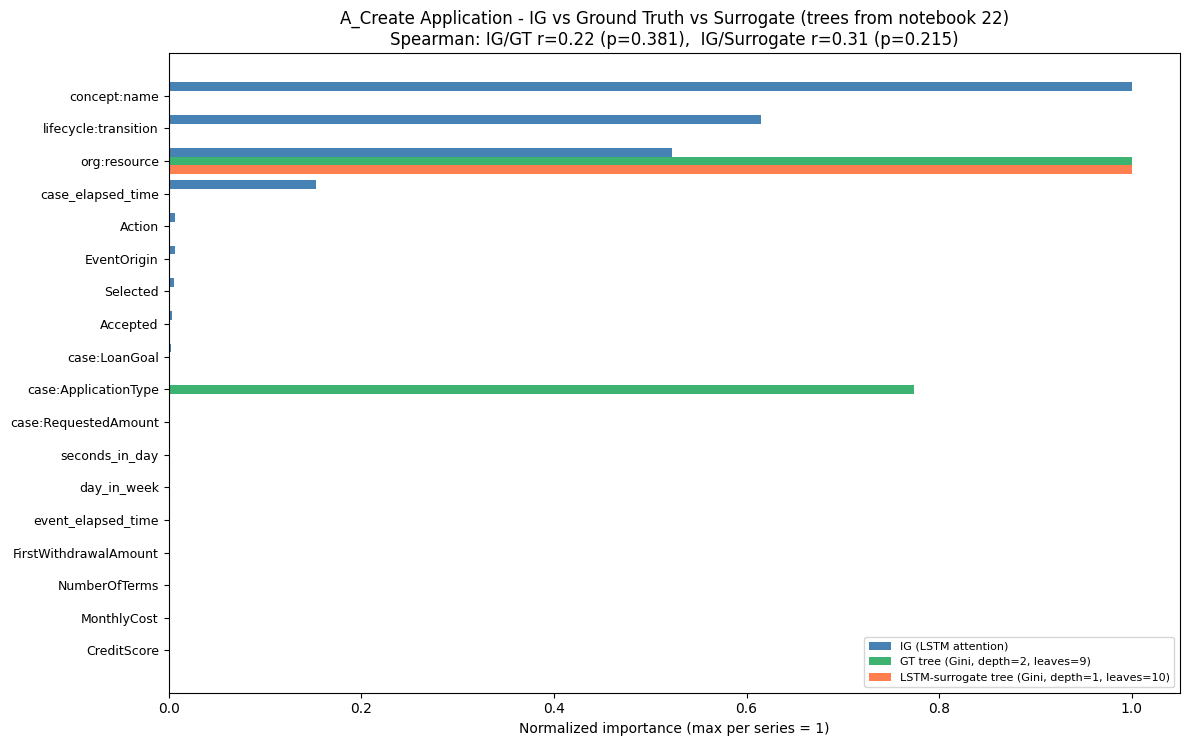


A_Create Application - Feature ranking comparison:


,feature,ig_mean,gt_gini,surrogate_gini
0,concept:name,1.2407,0.0000,0.0
4,lifecycle:transition,0.7637,0.0000,0.0
2,org:resource,0.6491,0.5637,1.0
9,case_elapsed_time,0.1900,0.0000,0.0
1,Action,0.0079,0.0000,0.0
3,EventOrigin,0.0079,0.0000,0.0
8,Selected,0.0067,0.0000,0.0
7,Accepted,0.0049,0.0000,0.0
5,case:LoanGoal,0.0037,0.0000,0.0
6,case:ApplicationType,0.0021,0.4363,0.0


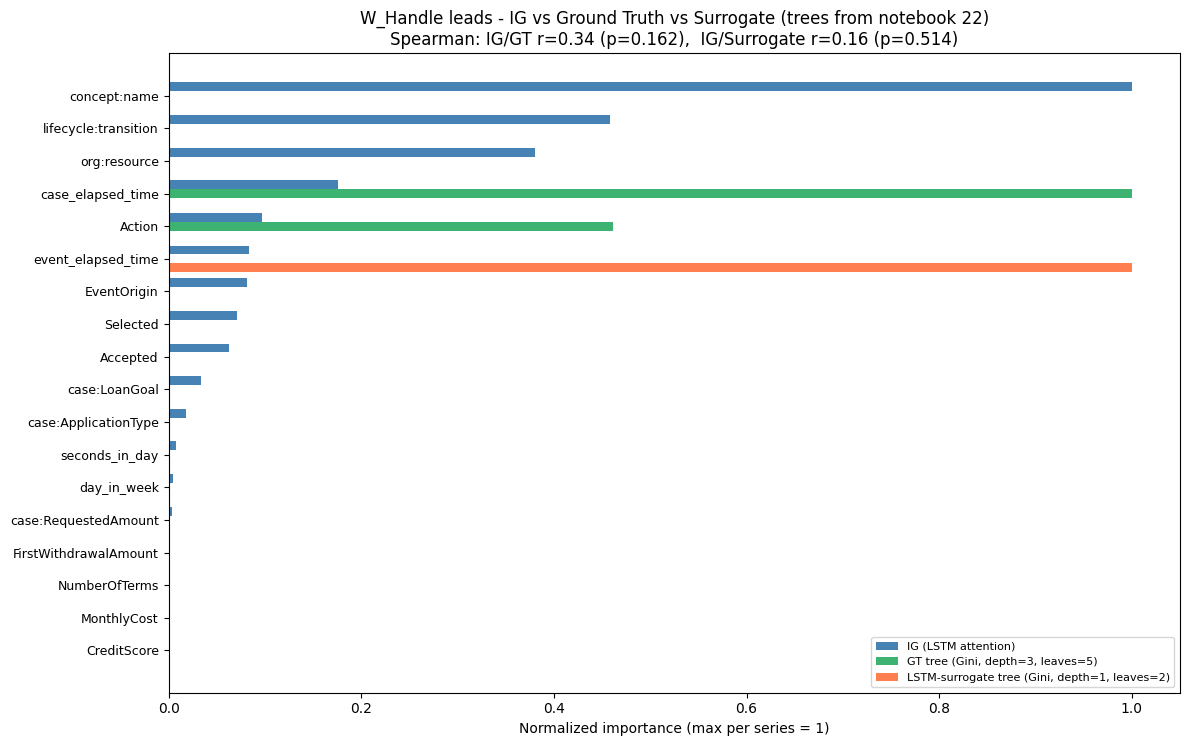


W_Handle leads - Feature ranking comparison:


,feature,ig_mean,gt_gini,surrogate_gini
0,concept:name,1.4591,0.0000,0.0
4,lifecycle:transition,0.6688,0.0000,0.0
2,org:resource,0.5553,0.0000,0.0
9,case_elapsed_time,0.2565,0.5152,0.0
1,Action,0.1417,0.2379,0.0
10,event_elapsed_time,0.1212,0.0000,1.0
3,EventOrigin,0.1180,0.0000,0.0
8,Selected,0.1040,0.0000,0.0
7,Accepted,0.0910,0.0000,0.0
5,case:LoanGoal,0.0488,0.0000,0.0


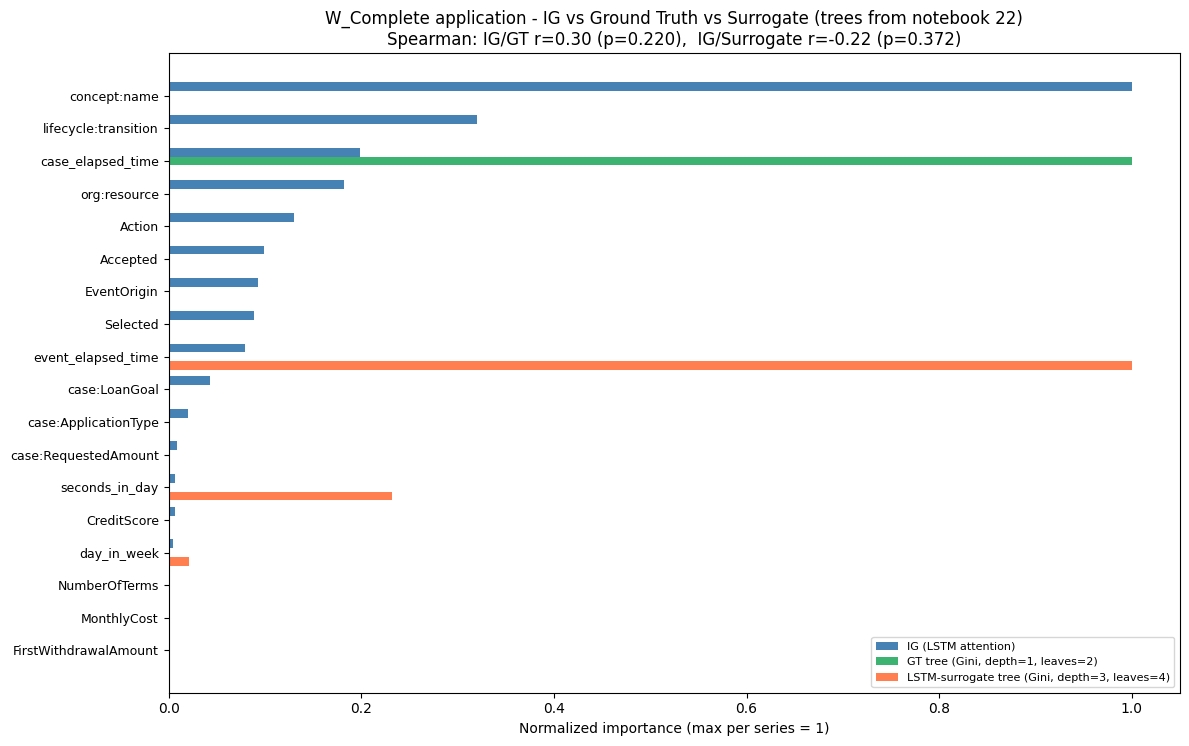


W_Complete application - Feature ranking comparison:


,feature,ig_mean,gt_gini,surrogate_gini
0,concept:name,2.4051,0.0,0.0000
4,lifecycle:transition,0.7709,0.0,0.0000
9,case_elapsed_time,0.4773,1.0,0.0000
2,org:resource,0.4388,0.0,0.0000
1,Action,0.3135,0.0,0.0000
7,Accepted,0.2386,0.0,0.0000
3,EventOrigin,0.2239,0.0,0.0000
8,Selected,0.2122,0.0,0.0000
10,event_elapsed_time,0.1914,0.0,0.7983
5,case:LoanGoal,0.1024,0.0,0.0000


/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_92829/1163611142.py:36: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_gt, p_gt = spearmanr(comp_df['ig_mean'], comp_df['gt_gini'])
/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_92829/1163611142.py:37: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_surr, p_surr = spearmanr(comp_df['ig_mean'], comp_df['surrogate_gini'])


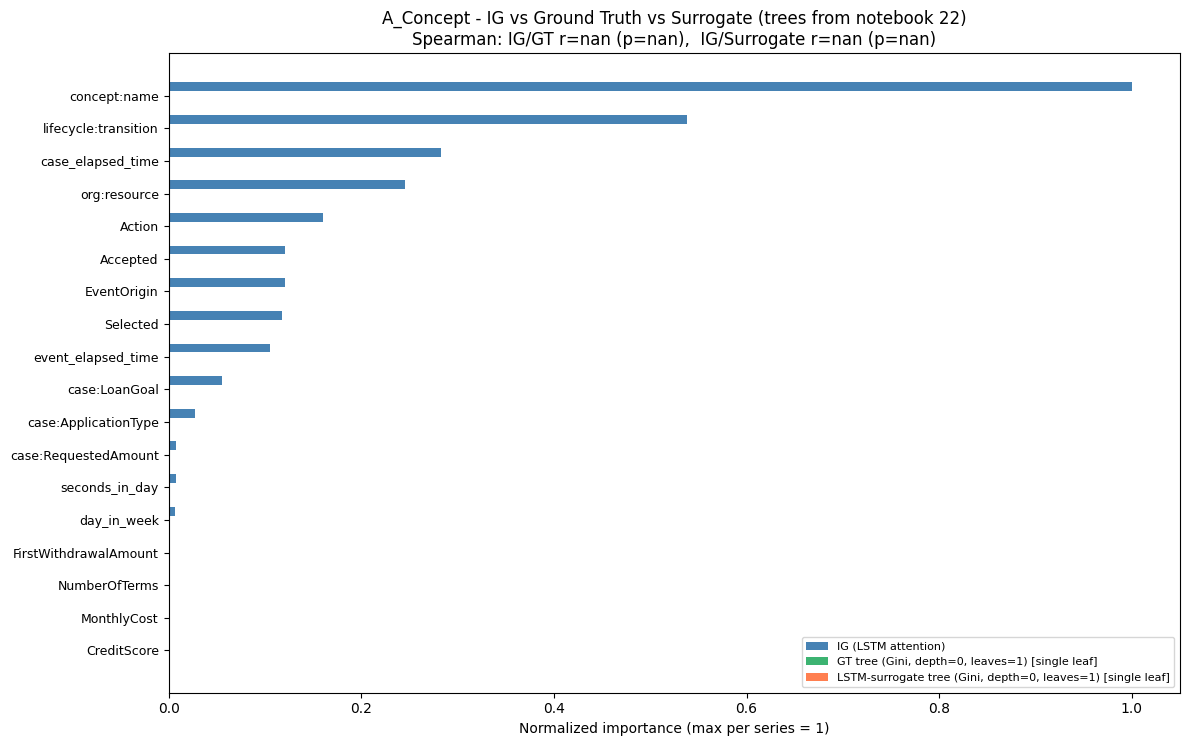


A_Concept - Feature ranking comparison:


,feature,ig_mean,gt_gini,surrogate_gini
0,concept:name,1.6270,0.0,0.0
4,lifecycle:transition,0.8752,0.0,0.0
9,case_elapsed_time,0.4593,0.0,0.0
2,org:resource,0.3985,0.0,0.0
1,Action,0.2606,0.0,0.0
7,Accepted,0.1966,0.0,0.0
3,EventOrigin,0.1966,0.0,0.0
8,Selected,0.1920,0.0,0.0
10,event_elapsed_time,0.1712,0.0,0.0
5,case:LoanGoal,0.0909,0.0,0.0


/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_92829/1163611142.py:36: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_gt, p_gt = spearmanr(comp_df['ig_mean'], comp_df['gt_gini'])


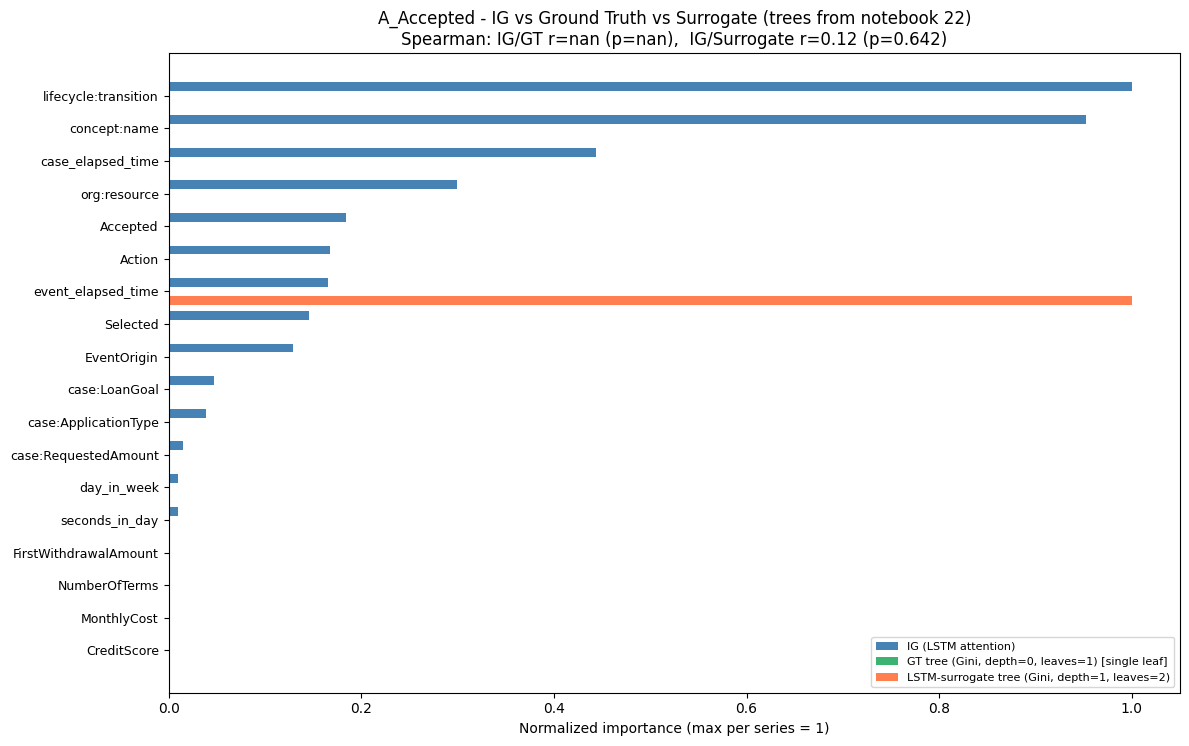


A_Accepted - Feature ranking comparison:


,feature,ig_mean,gt_gini,surrogate_gini
4,lifecycle:transition,1.3005,0.0,0.0
0,concept:name,1.2389,0.0,0.0
9,case_elapsed_time,0.5768,0.0,0.0
2,org:resource,0.3890,0.0,0.0
7,Accepted,0.2395,0.0,0.0
1,Action,0.2174,0.0,0.0
10,event_elapsed_time,0.2154,0.0,1.0
8,Selected,0.1896,0.0,0.0
3,EventOrigin,0.1682,0.0,0.0
5,case:LoanGoal,0.0618,0.0,0.0


/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_92829/1163611142.py:37: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_surr, p_surr = spearmanr(comp_df['ig_mean'], comp_df['surrogate_gini'])


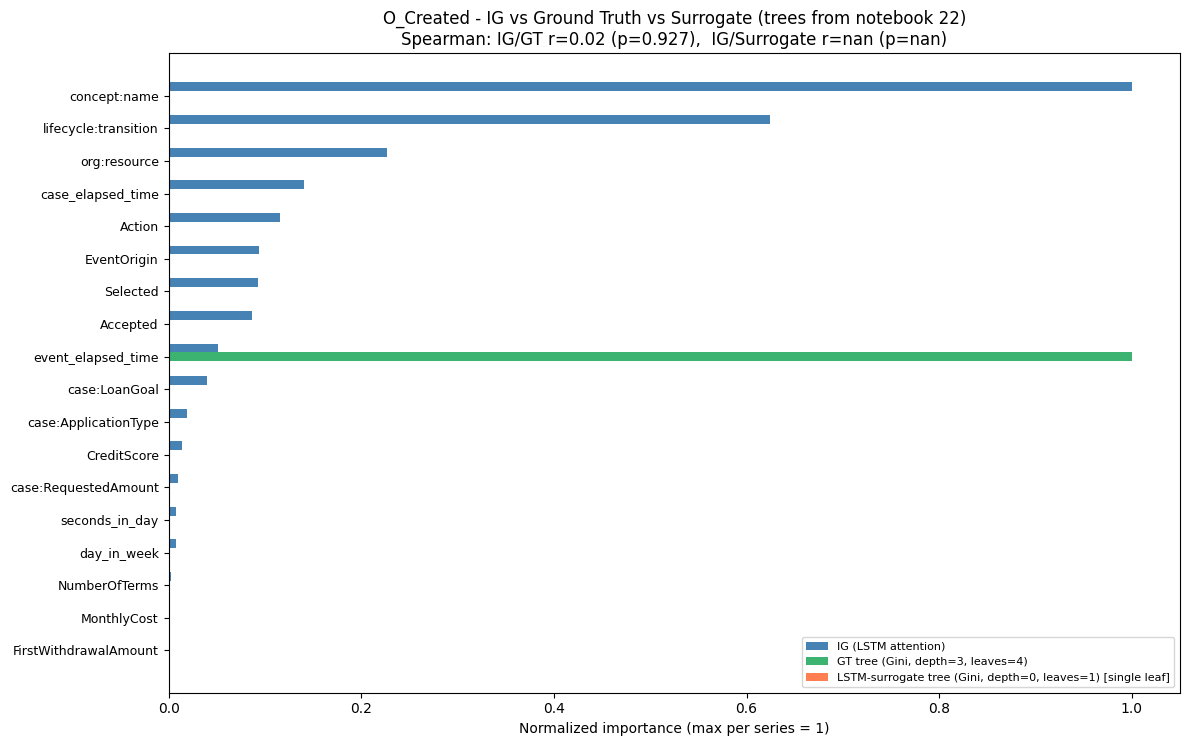


O_Created - Feature ranking comparison:


,feature,ig_mean,gt_gini,surrogate_gini
0,concept:name,2.3815,0.000,0.0
4,lifecycle:transition,1.4860,0.000,0.0
2,org:resource,0.5391,0.000,0.0
9,case_elapsed_time,0.3341,0.000,0.0
1,Action,0.2764,0.000,0.0
3,EventOrigin,0.2245,0.000,0.0
8,Selected,0.2220,0.000,0.0
7,Accepted,0.2059,0.000,0.0
10,event_elapsed_time,0.1216,0.889,0.0
5,case:LoanGoal,0.0947,0.000,0.0


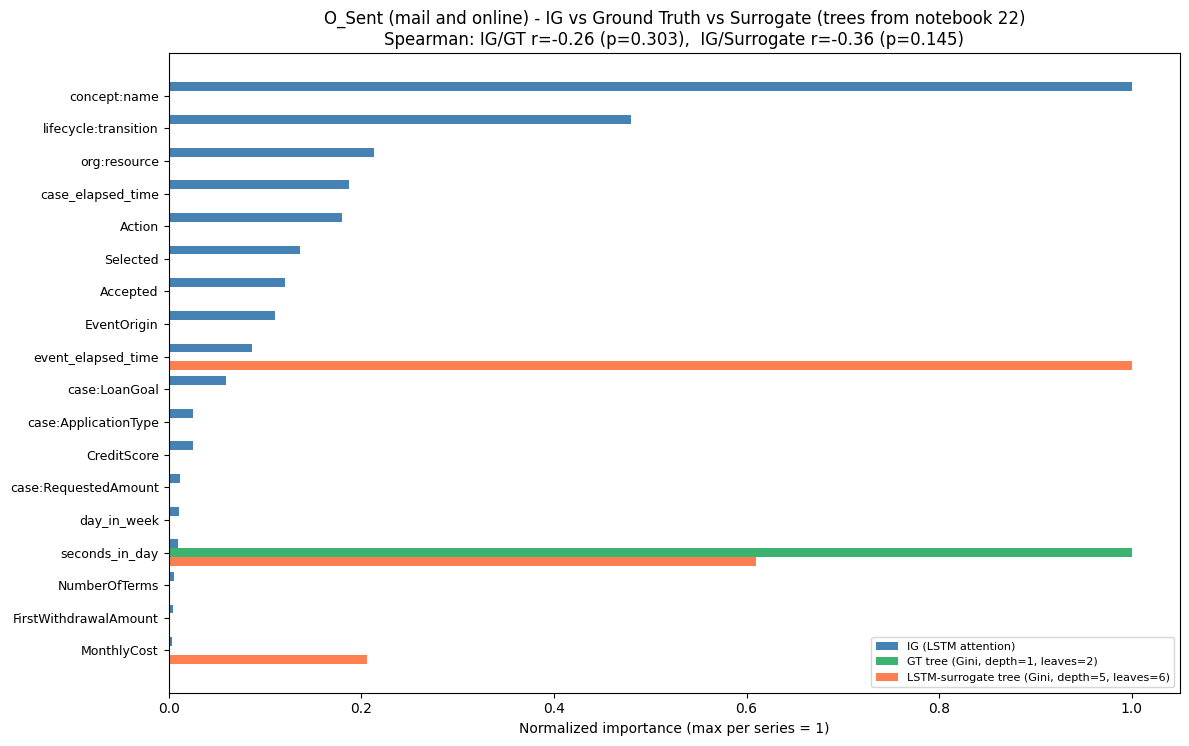


O_Sent (mail and online) - Feature ranking comparison:


,feature,ig_mean,gt_gini,surrogate_gini
0,concept:name,2.4339,0.0,0.0000
4,lifecycle:transition,1.1695,0.0,0.0000
2,org:resource,0.5185,0.0,0.0000
9,case_elapsed_time,0.4553,0.0,0.0000
1,Action,0.4394,0.0,0.0000
8,Selected,0.3309,0.0,0.0000
7,Accepted,0.2930,0.0,0.0000
3,EventOrigin,0.2697,0.0,0.0000
10,event_elapsed_time,0.2110,0.0,0.4764
5,case:LoanGoal,0.1459,0.0,0.0000


/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_92829/1163611142.py:36: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_gt, p_gt = spearmanr(comp_df['ig_mean'], comp_df['gt_gini'])


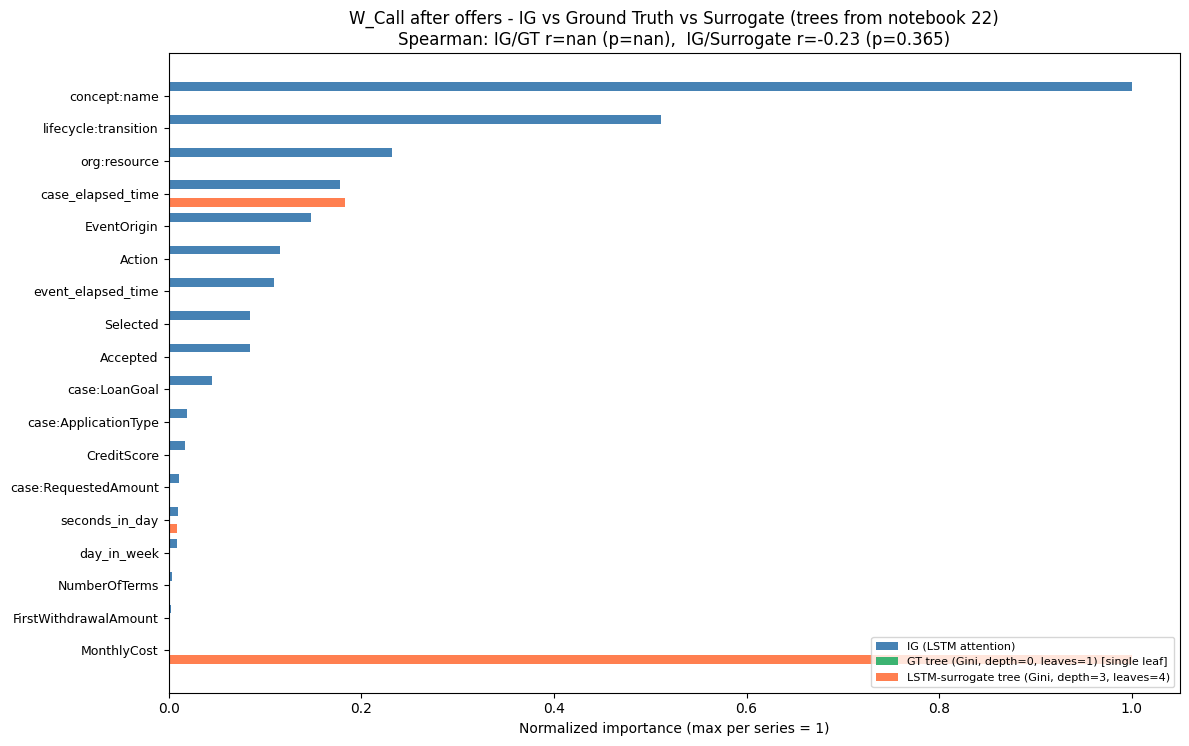


W_Call after offers - Feature ranking comparison:


,feature,ig_mean,gt_gini,surrogate_gini
0,concept:name,3.0657,0.0,0.0000
4,lifecycle:transition,1.5660,0.0,0.0000
2,org:resource,0.7114,0.0,0.0000
9,case_elapsed_time,0.5448,0.0,0.1539
3,EventOrigin,0.4541,0.0,0.0000
1,Action,0.3548,0.0,0.0000
10,event_elapsed_time,0.3359,0.0,0.0000
8,Selected,0.2583,0.0,0.0000
7,Accepted,0.2581,0.0,0.0000
5,case:LoanGoal,0.1371,0.0,0.0000


/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_92829/1163611142.py:36: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_gt, p_gt = spearmanr(comp_df['ig_mean'], comp_df['gt_gini'])
/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_92829/1163611142.py:37: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_surr, p_surr = spearmanr(comp_df['ig_mean'], comp_df['surrogate_gini'])


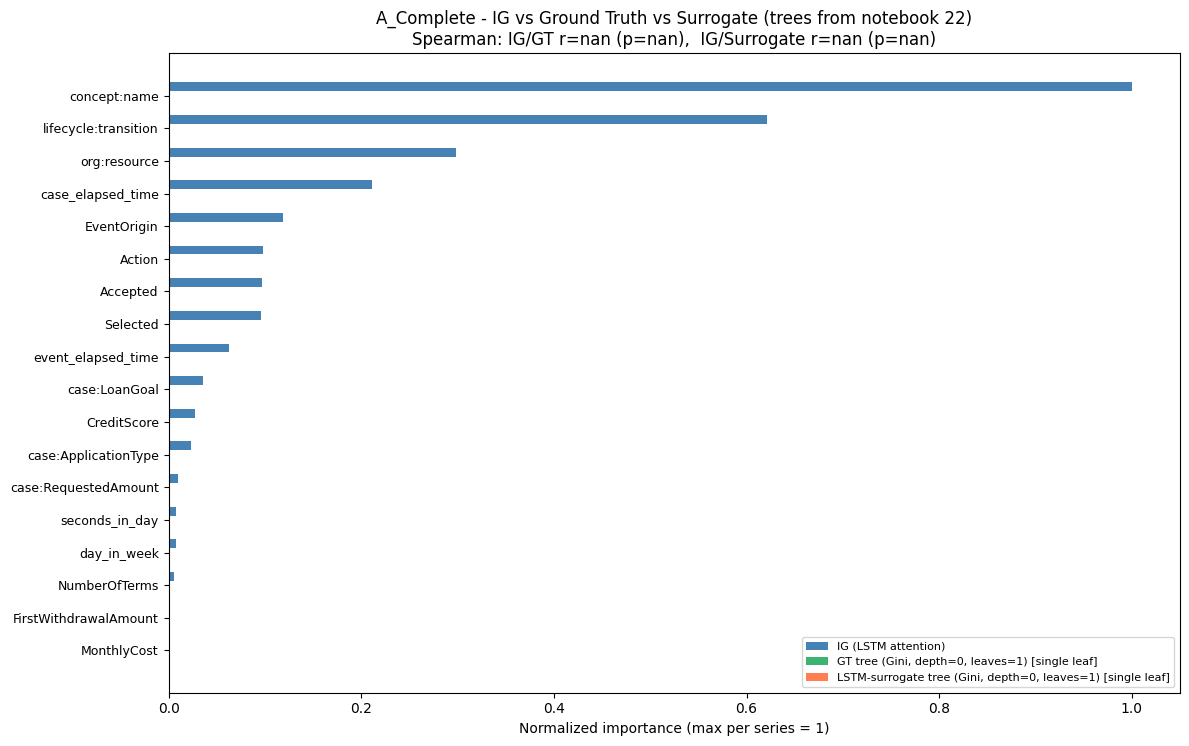


A_Complete - Feature ranking comparison:


,feature,ig_mean,gt_gini,surrogate_gini
0,concept:name,2.5452,0.0,0.0
4,lifecycle:transition,1.5799,0.0,0.0
2,org:resource,0.7593,0.0,0.0
9,case_elapsed_time,0.5365,0.0,0.0
3,EventOrigin,0.3023,0.0,0.0
1,Action,0.2496,0.0,0.0
7,Accepted,0.2464,0.0,0.0
8,Selected,0.2449,0.0,0.0
10,event_elapsed_time,0.1602,0.0,0.0
5,case:LoanGoal,0.0900,0.0,0.0


/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_92829/1163611142.py:36: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_gt, p_gt = spearmanr(comp_df['ig_mean'], comp_df['gt_gini'])
/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_92829/1163611142.py:37: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_surr, p_surr = spearmanr(comp_df['ig_mean'], comp_df['surrogate_gini'])


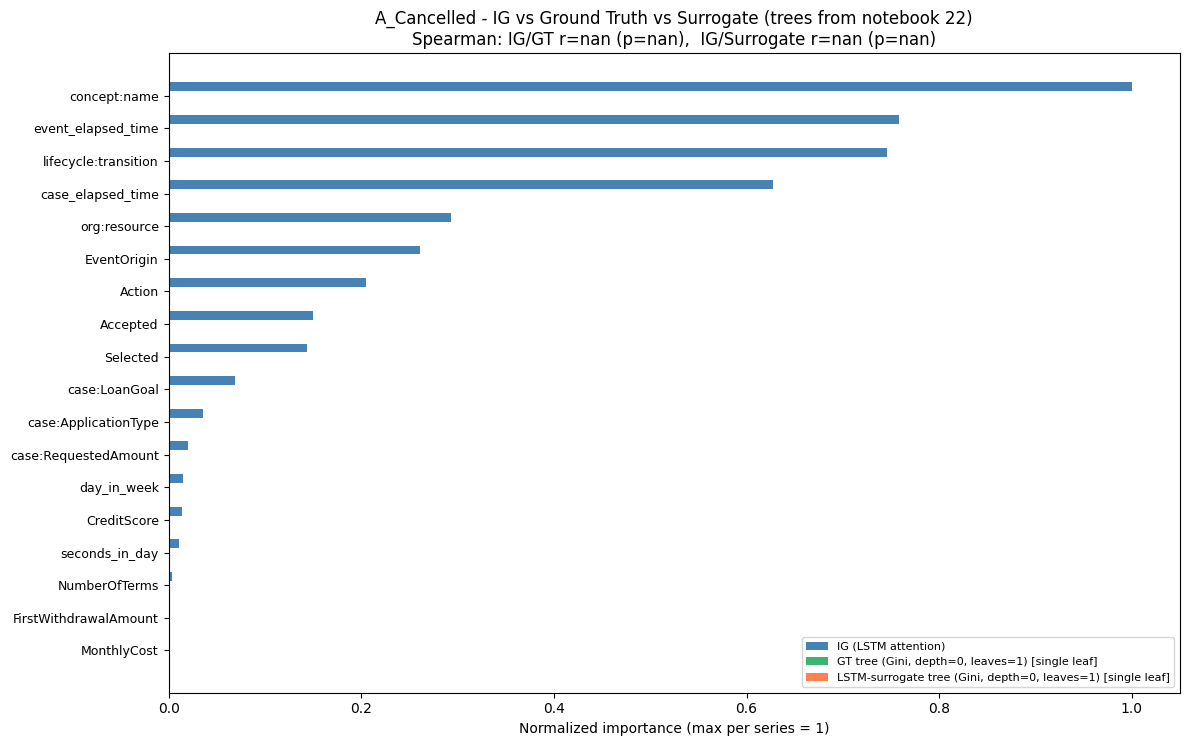


A_Cancelled - Feature ranking comparison:


,feature,ig_mean,gt_gini,surrogate_gini
0,concept:name,1.4042,0.0,0.0
10,event_elapsed_time,1.0642,0.0,0.0
4,lifecycle:transition,1.0477,0.0,0.0
9,case_elapsed_time,0.8809,0.0,0.0
2,org:resource,0.4112,0.0,0.0
3,EventOrigin,0.3662,0.0,0.0
1,Action,0.2880,0.0,0.0
7,Accepted,0.2099,0.0,0.0
8,Selected,0.2016,0.0,0.0
5,case:LoanGoal,0.0975,0.0,0.0


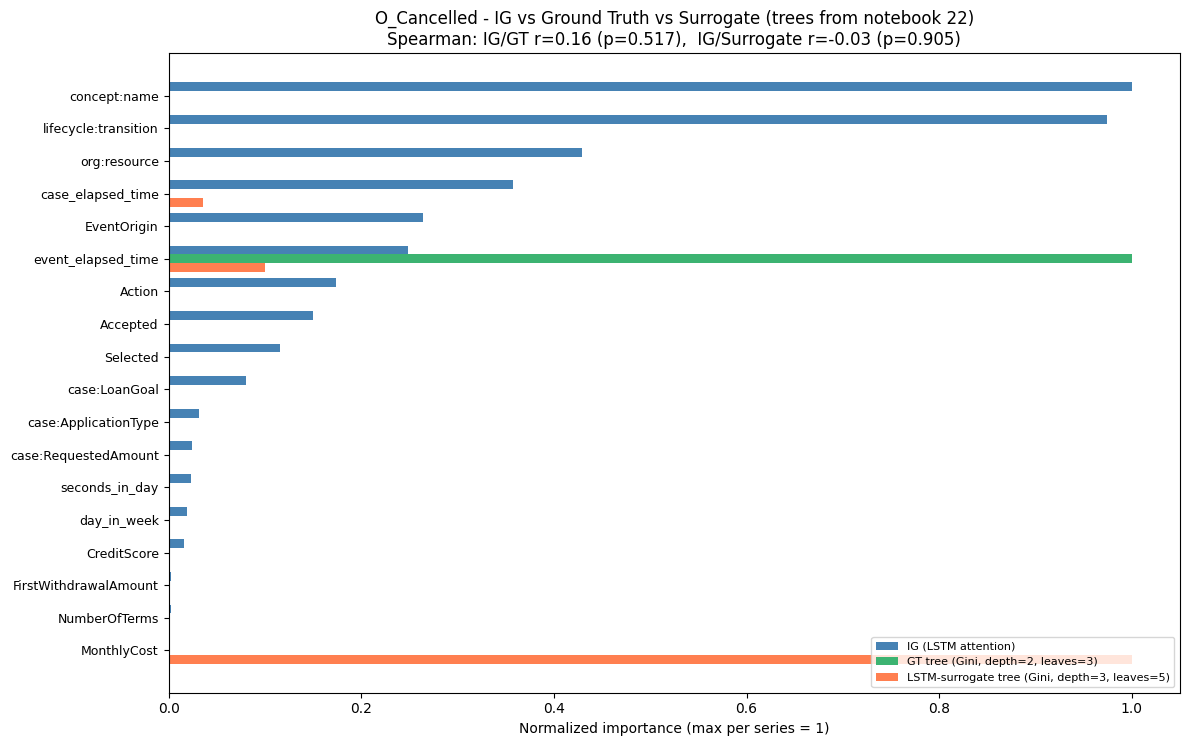


O_Cancelled - Feature ranking comparison:


,feature,ig_mean,gt_gini,surrogate_gini
0,concept:name,2.3556,0.0000,0.0000
4,lifecycle:transition,2.2949,0.0000,0.0000
2,org:resource,1.0100,0.0000,0.0000
9,case_elapsed_time,0.8430,0.0000,0.0315
3,EventOrigin,0.6215,0.0000,0.0000
10,event_elapsed_time,0.5853,0.9631,0.0872
1,Action,0.4098,0.0000,0.0000
7,Accepted,0.3542,0.0000,0.0000
8,Selected,0.2737,0.0000,0.0000
5,case:LoanGoal,0.1899,0.0000,0.0000


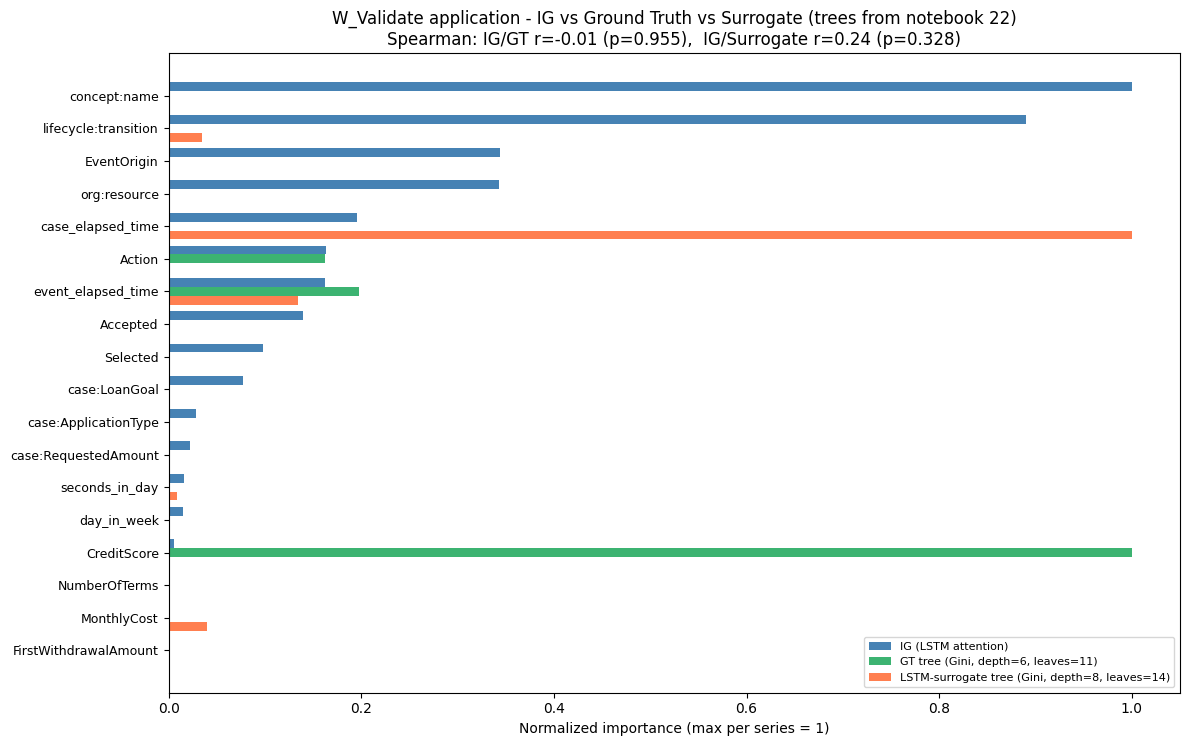


W_Validate application - Feature ranking comparison:


,feature,ig_mean,gt_gini,surrogate_gini
0,concept:name,2.0531,0.0000,0.0003
4,lifecycle:transition,1.8265,0.0000,0.0274
3,EventOrigin,0.7058,0.0000,0.0000
2,org:resource,0.7033,0.0000,0.0000
9,case_elapsed_time,0.4006,0.0000,0.7897
1,Action,0.3359,0.0990,0.0000
10,event_elapsed_time,0.3337,0.1207,0.1065
7,Accepted,0.2868,0.0000,0.0000
8,Selected,0.2015,0.0000,0.0000
5,case:LoanGoal,0.1584,0.0000,0.0000


/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_92829/1163611142.py:37: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_surr, p_surr = spearmanr(comp_df['ig_mean'], comp_df['surrogate_gini'])


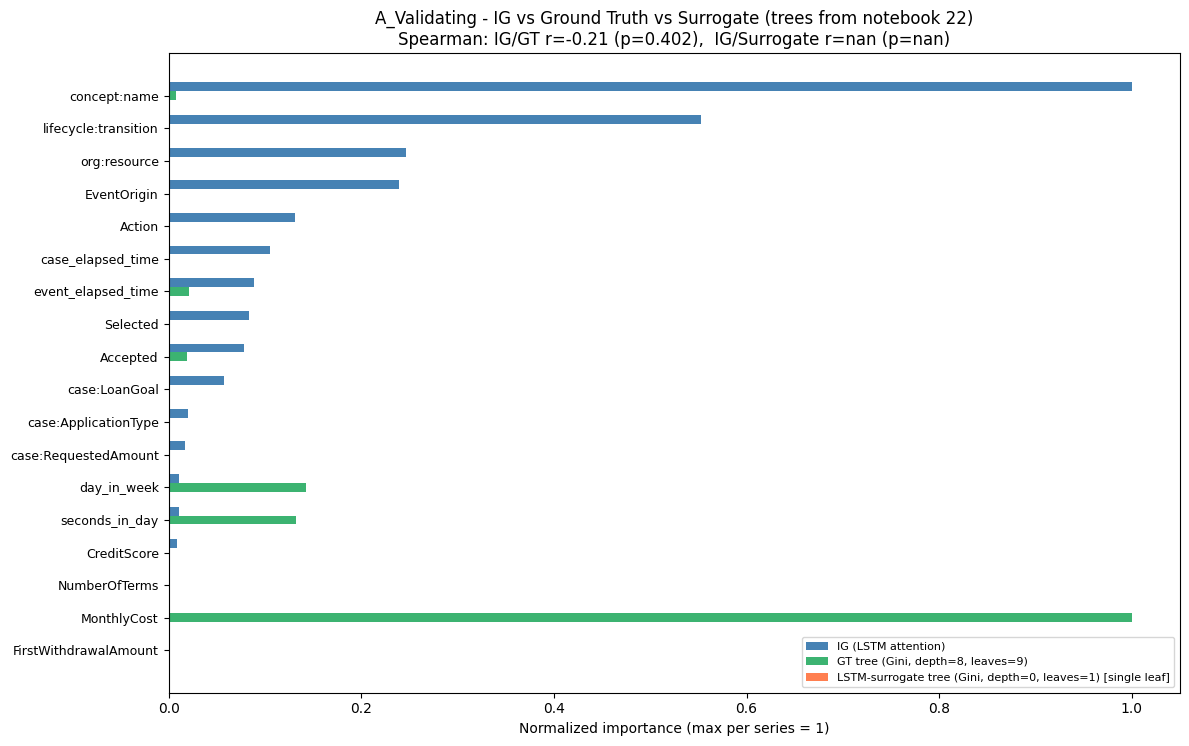


A_Validating - Feature ranking comparison:


,feature,ig_mean,gt_gini,surrogate_gini
0,concept:name,2.3824,0.0051,0.0
4,lifecycle:transition,1.3166,0.0000,0.0
2,org:resource,0.5875,0.0000,0.0
3,EventOrigin,0.5694,0.0000,0.0
1,Action,0.3115,0.0000,0.0
9,case_elapsed_time,0.2517,0.0000,0.0
10,event_elapsed_time,0.2121,0.0134,0.0
8,Selected,0.1988,0.0000,0.0
7,Accepted,0.1866,0.0121,0.0
5,case:LoanGoal,0.1371,0.0000,0.0


/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_92829/1163611142.py:37: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_surr, p_surr = spearmanr(comp_df['ig_mean'], comp_df['surrogate_gini'])


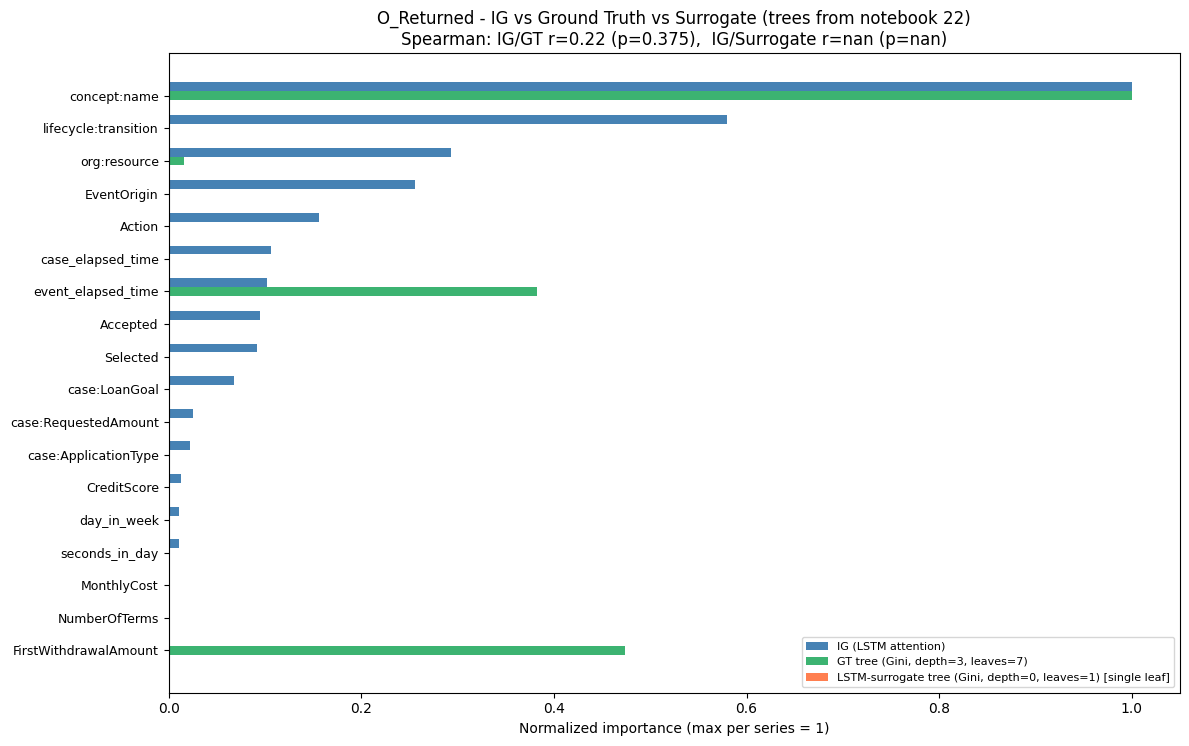


O_Returned - Feature ranking comparison:


,feature,ig_mean,gt_gini,surrogate_gini
0,concept:name,2.0200,0.5342,0.0
4,lifecycle:transition,1.1713,0.0000,0.0
2,org:resource,0.5928,0.0084,0.0
3,EventOrigin,0.5172,0.0000,0.0
1,Action,0.3158,0.0000,0.0
9,case_elapsed_time,0.2158,0.0000,0.0
10,event_elapsed_time,0.2055,0.2045,0.0
7,Accepted,0.1916,0.0000,0.0
8,Selected,0.1861,0.0000,0.0
5,case:LoanGoal,0.1382,0.0000,0.0


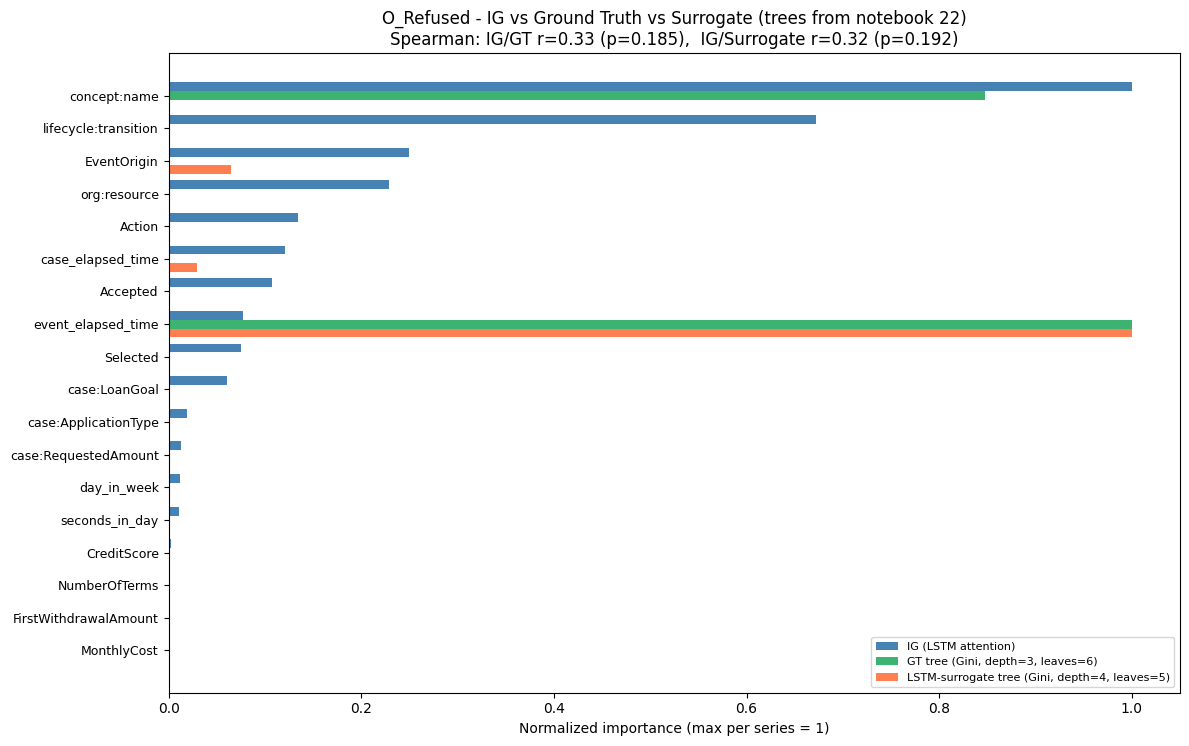


O_Refused - Feature ranking comparison:


,feature,ig_mean,gt_gini,surrogate_gini
0,concept:name,3.3395,0.4420,0.0000
4,lifecycle:transition,2.2458,0.0000,0.0000
3,EventOrigin,0.8348,0.0000,0.0464
2,org:resource,0.7658,0.0000,0.0000
1,Action,0.4491,0.0000,0.0000
9,case_elapsed_time,0.4046,0.0000,0.0215
7,Accepted,0.3595,0.0000,0.0000
10,event_elapsed_time,0.2575,0.5216,0.7198
8,Selected,0.2520,0.0000,0.0000
5,case:LoanGoal,0.2039,0.0000,0.0000


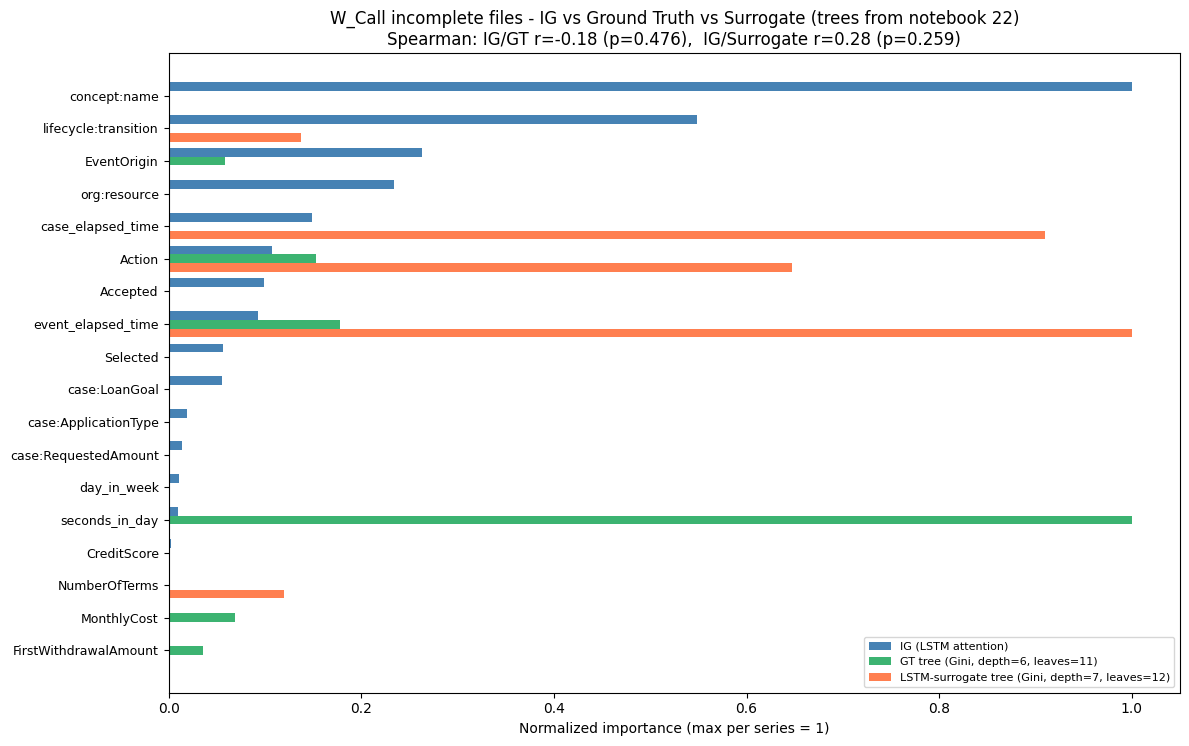


W_Call incomplete files - Feature ranking comparison:


,feature,ig_mean,gt_gini,surrogate_gini
0,concept:name,3.1503,0.0000,0.0000
4,lifecycle:transition,1.7290,0.0000,0.0453
3,EventOrigin,0.8274,0.0380,0.0000
2,org:resource,0.7385,0.0000,0.0000
9,case_elapsed_time,0.4695,0.0000,0.3000
1,Action,0.3382,0.1003,0.2135
7,Accepted,0.3121,0.0000,0.0000
10,event_elapsed_time,0.2927,0.1165,0.3297
8,Selected,0.1778,0.0000,0.0000
5,case:LoanGoal,0.1742,0.0000,0.0000


/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_92829/1163611142.py:36: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_gt, p_gt = spearmanr(comp_df['ig_mean'], comp_df['gt_gini'])
/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_92829/1163611142.py:37: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_surr, p_surr = spearmanr(comp_df['ig_mean'], comp_df['surrogate_gini'])


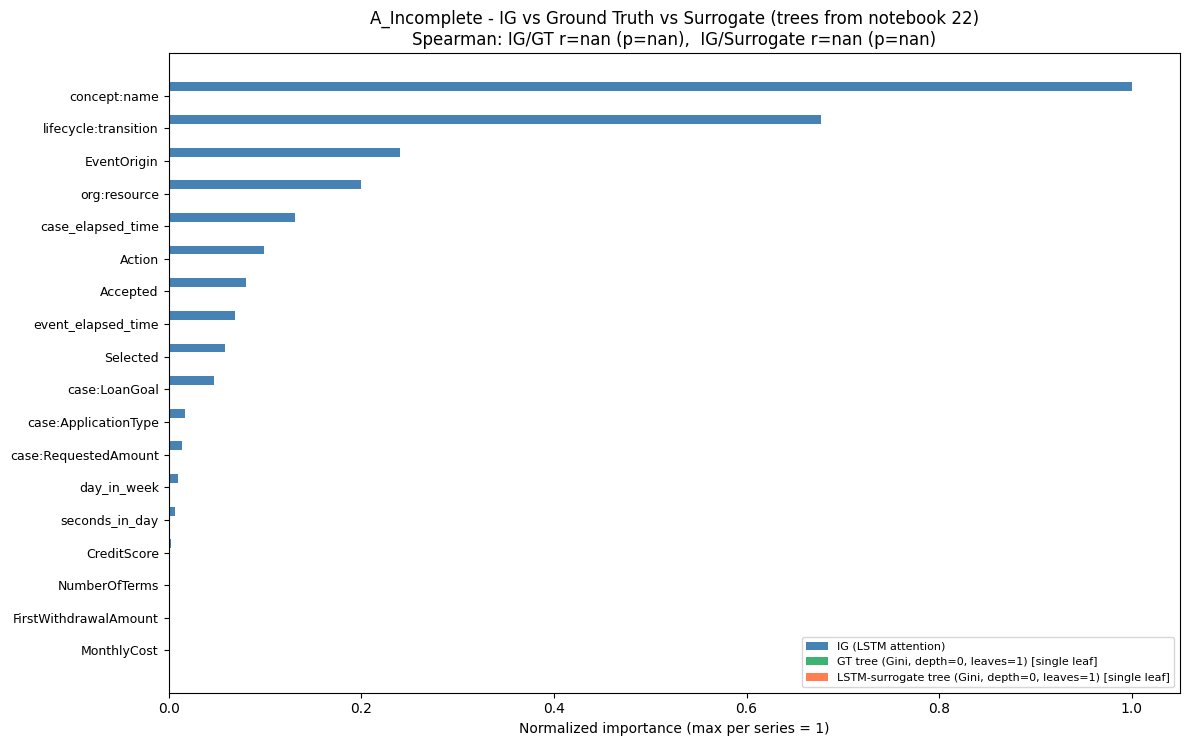


A_Incomplete - Feature ranking comparison:


,feature,ig_mean,gt_gini,surrogate_gini
0,concept:name,2.6025,0.0,0.0
4,lifecycle:transition,1.7628,0.0,0.0
3,EventOrigin,0.6245,0.0,0.0
2,org:resource,0.5202,0.0,0.0
9,case_elapsed_time,0.3414,0.0,0.0
1,Action,0.2583,0.0,0.0
7,Accepted,0.2102,0.0,0.0
10,event_elapsed_time,0.1788,0.0,0.0
8,Selected,0.1514,0.0,0.0
5,case:LoanGoal,0.1237,0.0,0.0


/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_92829/1163611142.py:36: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_gt, p_gt = spearmanr(comp_df['ig_mean'], comp_df['gt_gini'])


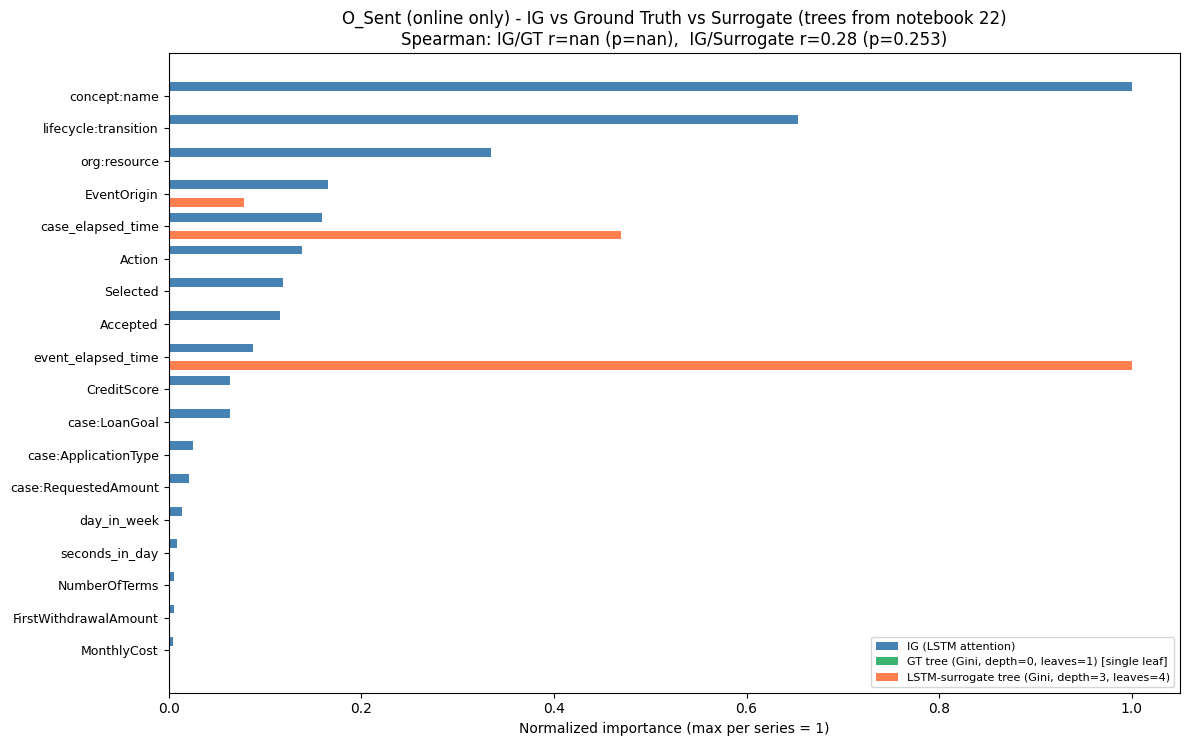


O_Sent (online only) - Feature ranking comparison:


,feature,ig_mean,gt_gini,surrogate_gini
0,concept:name,2.4333,0.0,0.0000
4,lifecycle:transition,1.5902,0.0,0.0000
2,org:resource,0.8147,0.0,0.0000
3,EventOrigin,0.4023,0.0,0.0503
9,case_elapsed_time,0.3872,0.0,0.3035
1,Action,0.3371,0.0,0.0000
8,Selected,0.2895,0.0,0.0000
7,Accepted,0.2822,0.0,0.0000
10,event_elapsed_time,0.2141,0.0,0.6462
17,CreditScore,0.1549,0.0,0.0000


/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_92829/1163611142.py:37: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_surr, p_surr = spearmanr(comp_df['ig_mean'], comp_df['surrogate_gini'])


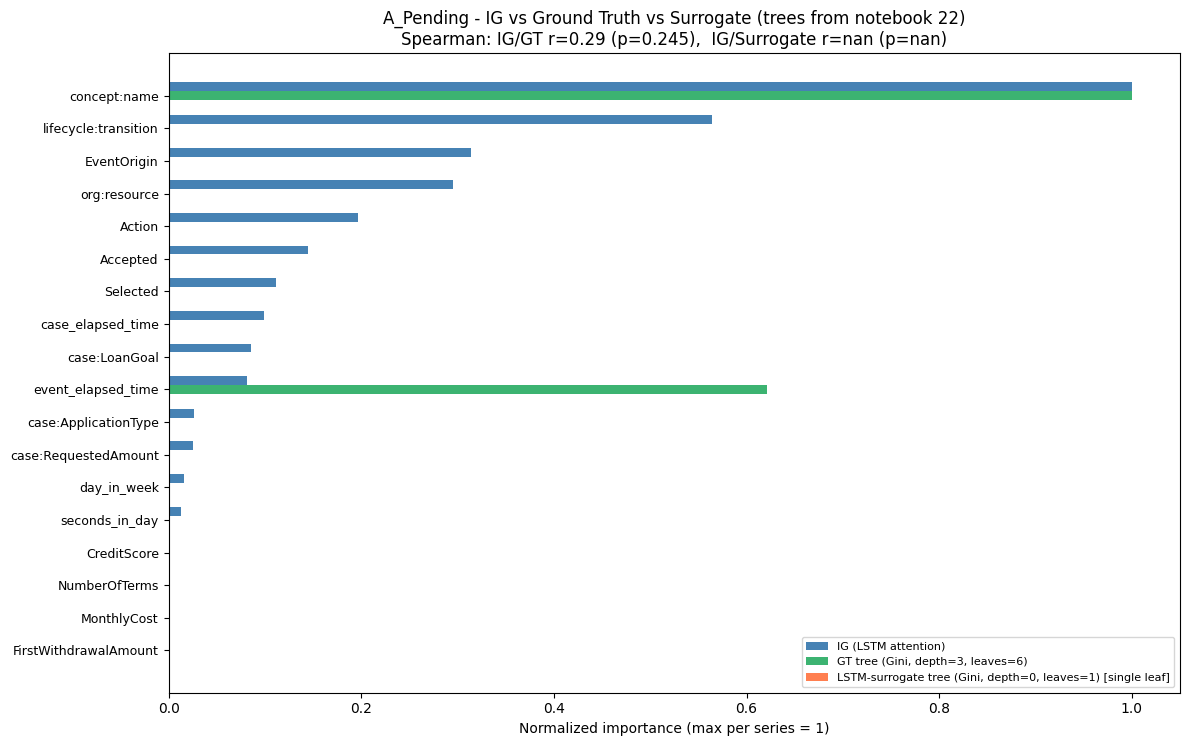


A_Pending - Feature ranking comparison:


,feature,ig_mean,gt_gini,surrogate_gini
0,concept:name,2.6568,0.4815,0.0
4,lifecycle:transition,1.4988,0.0000,0.0
3,EventOrigin,0.8334,0.0000,0.0
2,org:resource,0.7854,0.0000,0.0
1,Action,0.5217,0.0000,0.0
7,Accepted,0.3844,0.0000,0.0
8,Selected,0.2969,0.0000,0.0
9,case_elapsed_time,0.2642,0.0000,0.0
5,case:LoanGoal,0.2266,0.0000,0.0
10,event_elapsed_time,0.2153,0.2991,0.0


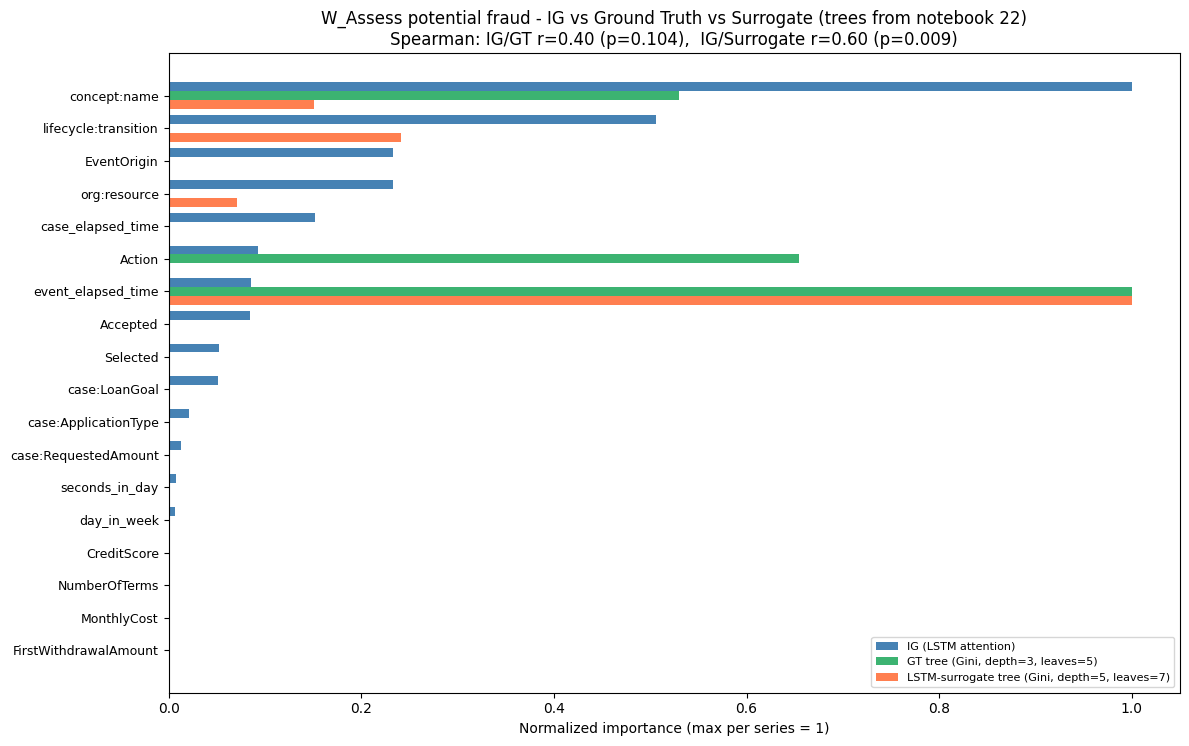


W_Assess potential fraud - Feature ranking comparison:


,feature,ig_mean,gt_gini,surrogate_gini
0,concept:name,3.3743,0.2426,0.0967
4,lifecycle:transition,1.7061,0.0000,0.1547
3,EventOrigin,0.7872,0.0000,0.0000
2,org:resource,0.7846,0.0000,0.0455
9,case_elapsed_time,0.5117,0.0000,0.0000
1,Action,0.3133,0.2996,0.0000
10,event_elapsed_time,0.2872,0.4578,0.6405
7,Accepted,0.2839,0.0000,0.0000
8,Selected,0.1782,0.0000,0.0000
5,case:LoanGoal,0.1717,0.0000,0.0000


/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_92829/1163611142.py:36: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_gt, p_gt = spearmanr(comp_df['ig_mean'], comp_df['gt_gini'])
/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_92829/1163611142.py:37: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_surr, p_surr = spearmanr(comp_df['ig_mean'], comp_df['surrogate_gini'])


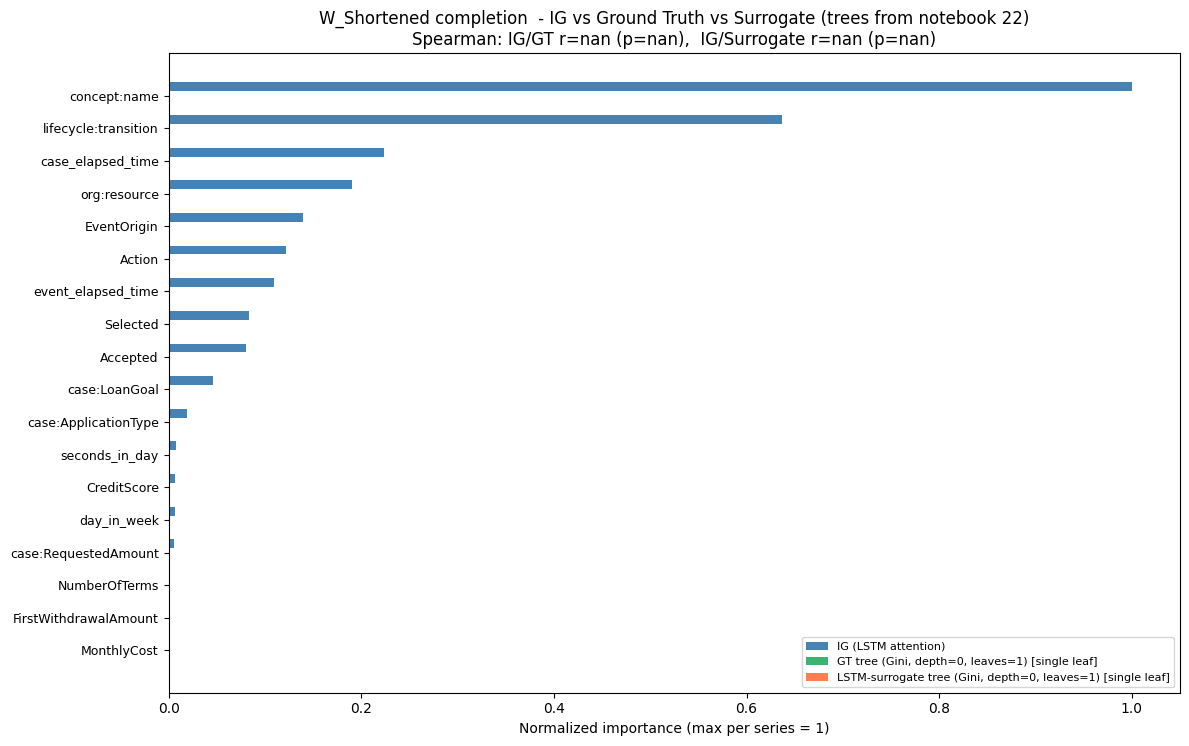


W_Shortened completion  - Feature ranking comparison:


,feature,ig_mean,gt_gini,surrogate_gini
0,concept:name,2.4038,0.0,0.0
4,lifecycle:transition,1.5313,0.0,0.0
9,case_elapsed_time,0.5378,0.0,0.0
2,org:resource,0.4585,0.0,0.0
3,EventOrigin,0.3355,0.0,0.0
1,Action,0.2938,0.0,0.0
10,event_elapsed_time,0.2620,0.0,0.0
8,Selected,0.1997,0.0,0.0
7,Accepted,0.1921,0.0,0.0
5,case:LoanGoal,0.1110,0.0,0.0


In [6]:
# 3-bar comparison: IG vs Ground-Truth tree (Gini) vs LSTM-Surrogate tree (Gini).
# Trees come from notebook 22's cache (loaded above), so they're identical to
# what 22 displayed. For each model input feature we collapse the engineered
# feature space (positional `<feat>_pos_-w` and `last_<feat>`) by max Gini.

def _aggregate_gini(model_feat, importances, feature_names):
    keys = [f for f in feature_names
            if f == f'last_{model_feat}'
            or f.startswith(f'{model_feat}_pos_')]
    imp_map = dict(zip(feature_names, importances))
    return max((imp_map.get(k, 0.0) for k in keys), default=0.0)


for gateway_act in ig_results:
    ig_df = ig_results[gateway_act]
    gr = gateway_results[gateway_act]

    ig_features = [f for f in ALL_FEATURES if f in ig_df.columns]
    ig_mean = ig_df[ig_features].mean()

    fnames = gr['feature_names']
    surr_imp = gr['clf_lstm'].feature_importances_
    gt_imp = gr['clf_gt'].feature_importances_

    rows = []
    for feat in ig_features:
        rows.append({
            'feature': feat,
            'ig_mean': float(ig_mean[feat]),
            'gt_gini': _aggregate_gini(feat, gt_imp, fnames),
            'surrogate_gini': _aggregate_gini(feat, surr_imp, fnames),
        })
    comp_df = pd.DataFrame(rows).sort_values('ig_mean', ascending=False)

    if len(comp_df) >= 2:
        rho_gt, p_gt = spearmanr(comp_df['ig_mean'], comp_df['gt_gini'])
        rho_surr, p_surr = spearmanr(comp_df['ig_mean'], comp_df['surrogate_gini'])
    else:
        rho_gt = rho_surr = float('nan'); p_gt = p_surr = float('nan')

    def safe_norm(arr):
        m = arr.max()
        return arr / m if m > 0 else arr

    ig_norm = safe_norm(comp_df['ig_mean'].values)
    gt_norm = safe_norm(comp_df['gt_gini'].values)
    surr_norm = safe_norm(comp_df['surrogate_gini'].values)

    gt_clf, surr_clf = gr['clf_gt'], gr['clf_lstm']
    gt_d, gt_l = gt_clf.get_depth(), gt_clf.get_n_leaves()
    surr_d, surr_l = surr_clf.get_depth(), surr_clf.get_n_leaves()
    gt_stub = ' [single leaf]' if gt_d == 0 else ''
    surr_stub = ' [single leaf]' if surr_d == 0 else ''

    fig, ax = plt.subplots(figsize=(12, max(4, len(comp_df) * 0.42)))
    y_pos = np.arange(len(comp_df))
    bar_h = 0.27

    ax.barh(y_pos - bar_h, ig_norm, bar_h, label='IG (LSTM attention)', color='steelblue')
    ax.barh(y_pos,         gt_norm, bar_h,
            label=f'GT tree (Gini, depth={gt_d}, leaves={gt_l}){gt_stub}',
            color='mediumseagreen')
    ax.barh(y_pos + bar_h, surr_norm, bar_h,
            label=f'LSTM-surrogate tree (Gini, depth={surr_d}, leaves={surr_l}){surr_stub}',
            color='coral')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(comp_df['feature'].values, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Normalized importance (max per series = 1)')
    ax.set_title(
        f'{gateway_act} - IG vs Ground Truth vs Surrogate (trees from notebook 22)\n'
        f'Spearman: IG/GT r={rho_gt:.2f} (p={p_gt:.3f}),  '
        f'IG/Surrogate r={rho_surr:.2f} (p={p_surr:.3f})'
    )
    ax.legend(fontsize=8, loc='lower right')

    plt.tight_layout()
    plt.show()

    print(f'\n{gateway_act} - Feature ranking comparison:')
    display(comp_df.round(4))


## IG attribution: correct vs incorrect predictions

When the LSTM gets the gateway wrong, which features is it over- or
under-weighting compared to when it gets it right?

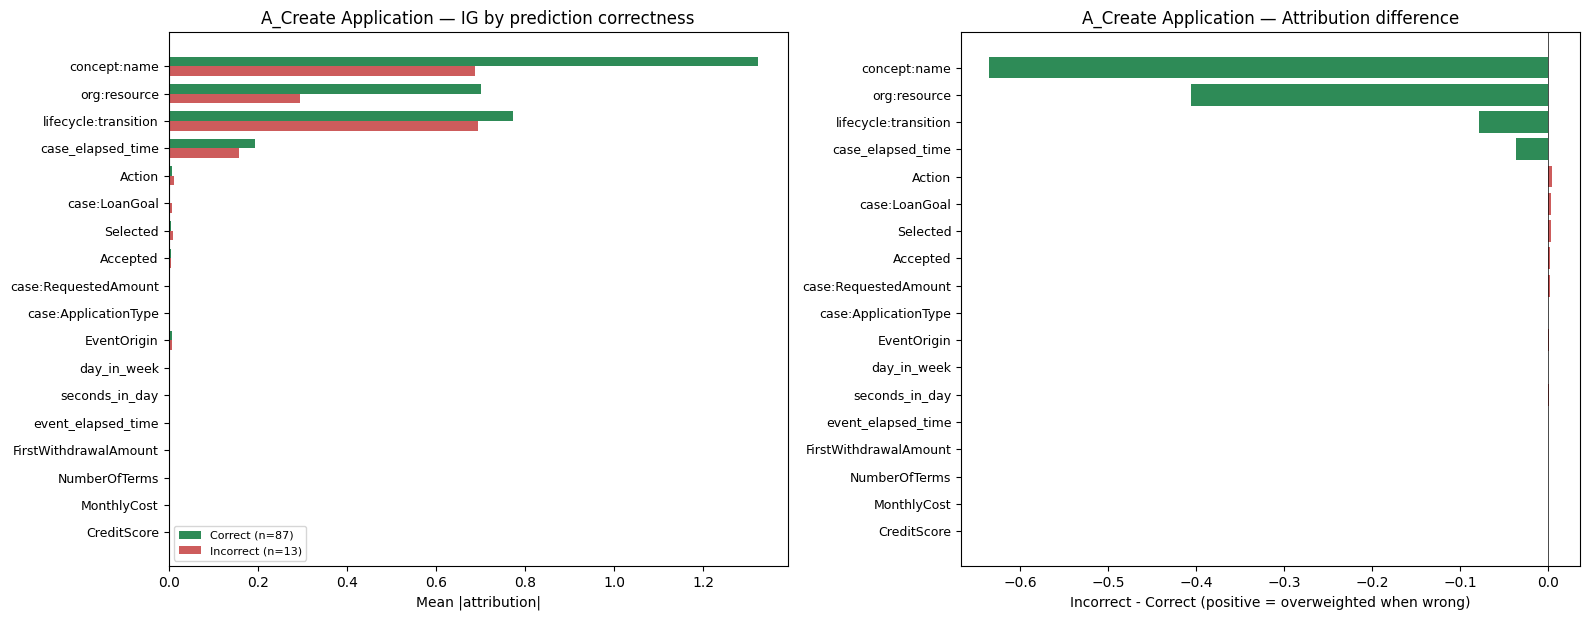

  Overweighted when wrong: Action (+0.0040), case:LoanGoal (+0.0035), Selected (+0.0034)
  Underweighted when wrong: concept:name (-0.6352), org:resource (-0.4057), lifecycle:transition (-0.0785)


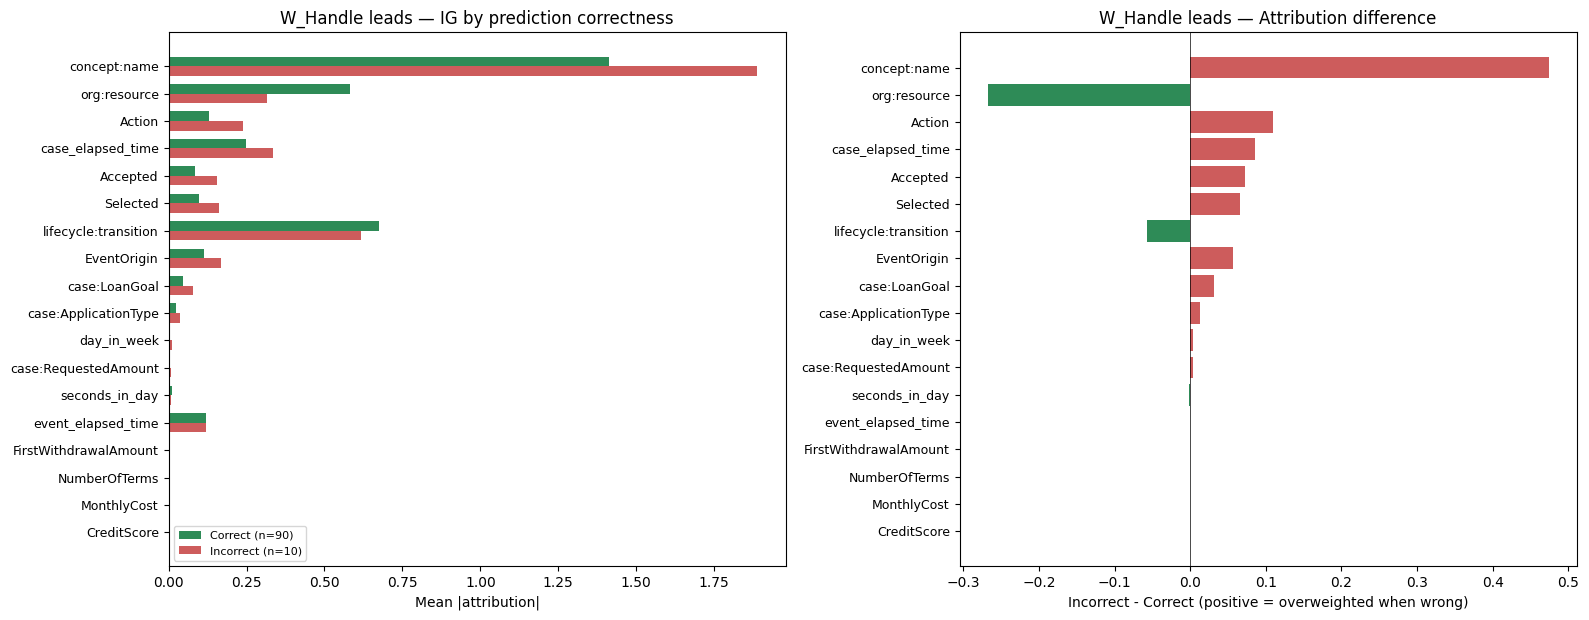

  Overweighted when wrong: concept:name (+0.4742), Action (+0.1090), case_elapsed_time (+0.0863)
  Underweighted when wrong: org:resource (-0.2679), lifecycle:transition (-0.0571), seconds_in_day (-0.0018)


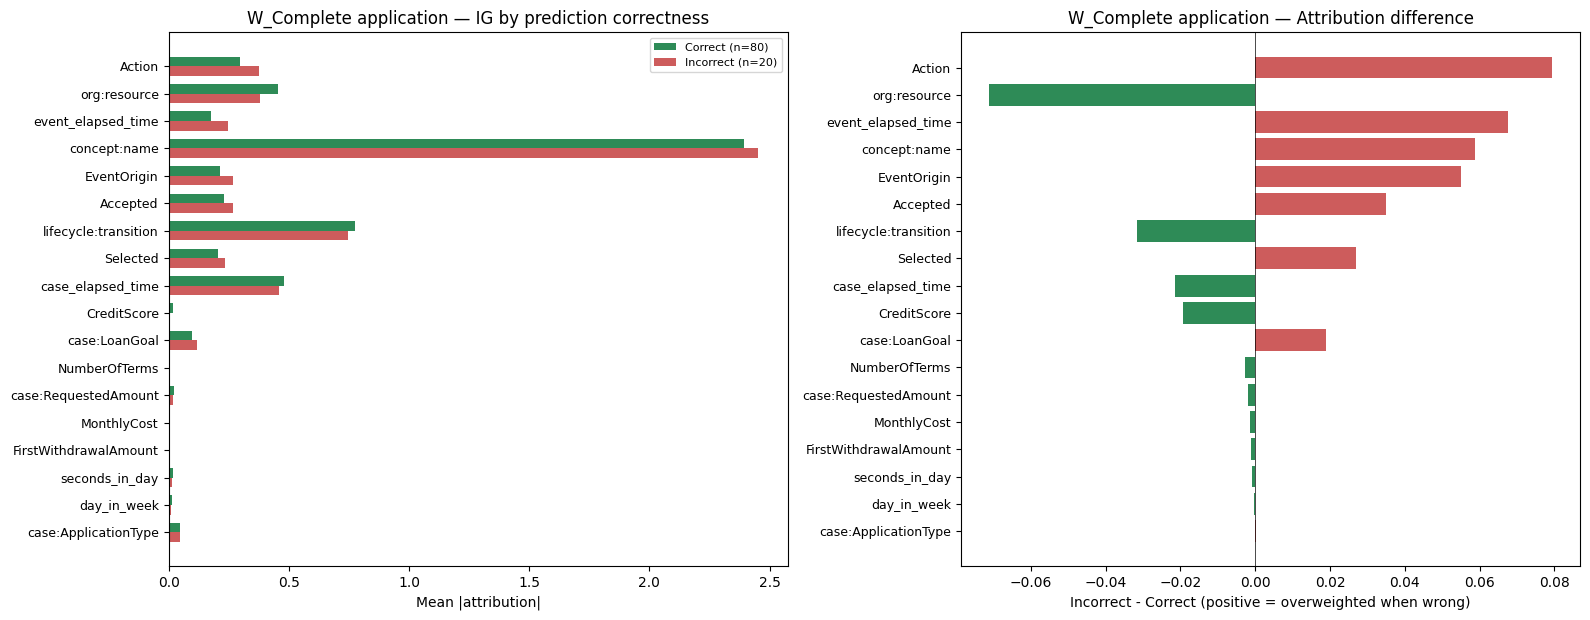

  Overweighted when wrong: Action (+0.0793), event_elapsed_time (+0.0676), concept:name (+0.0587)
  Underweighted when wrong: org:resource (-0.0711), lifecycle:transition (-0.0316), case_elapsed_time (-0.0216)


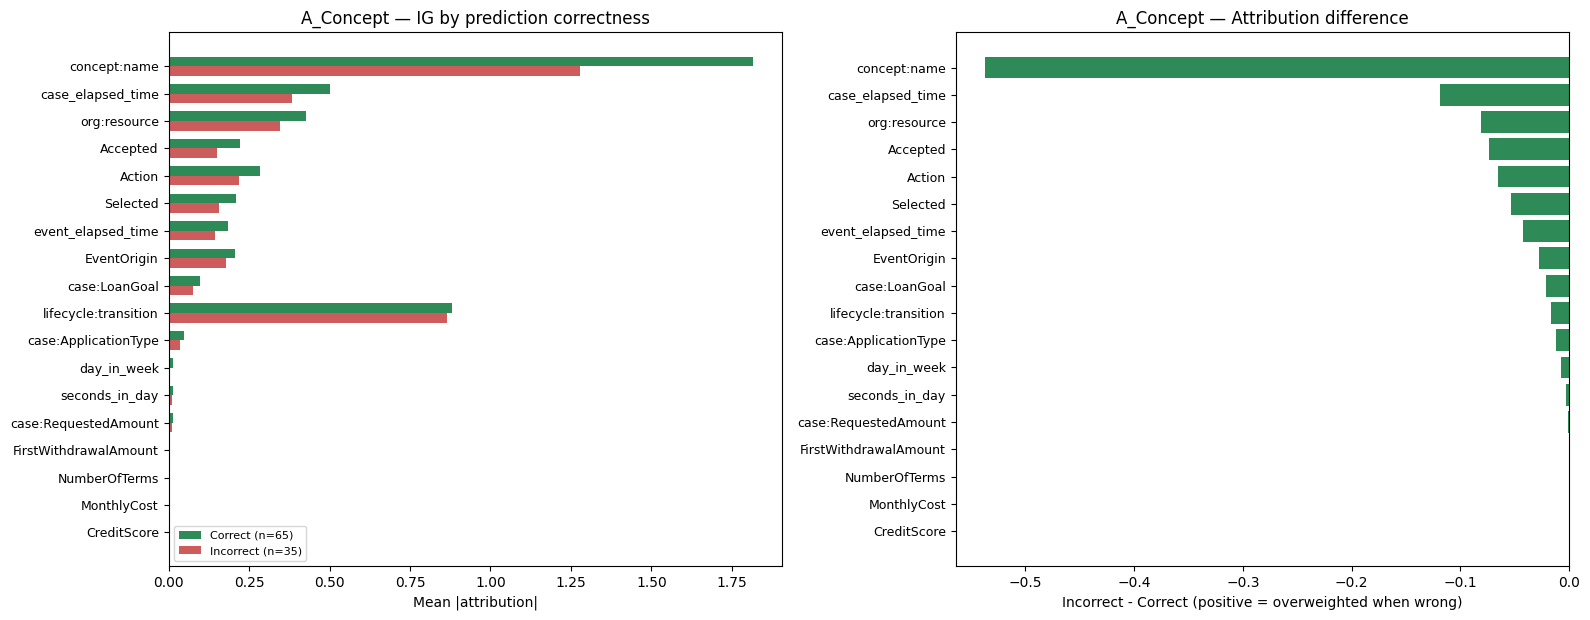

  Underweighted when wrong: concept:name (-0.5372), case_elapsed_time (-0.1182), org:resource (-0.0807)


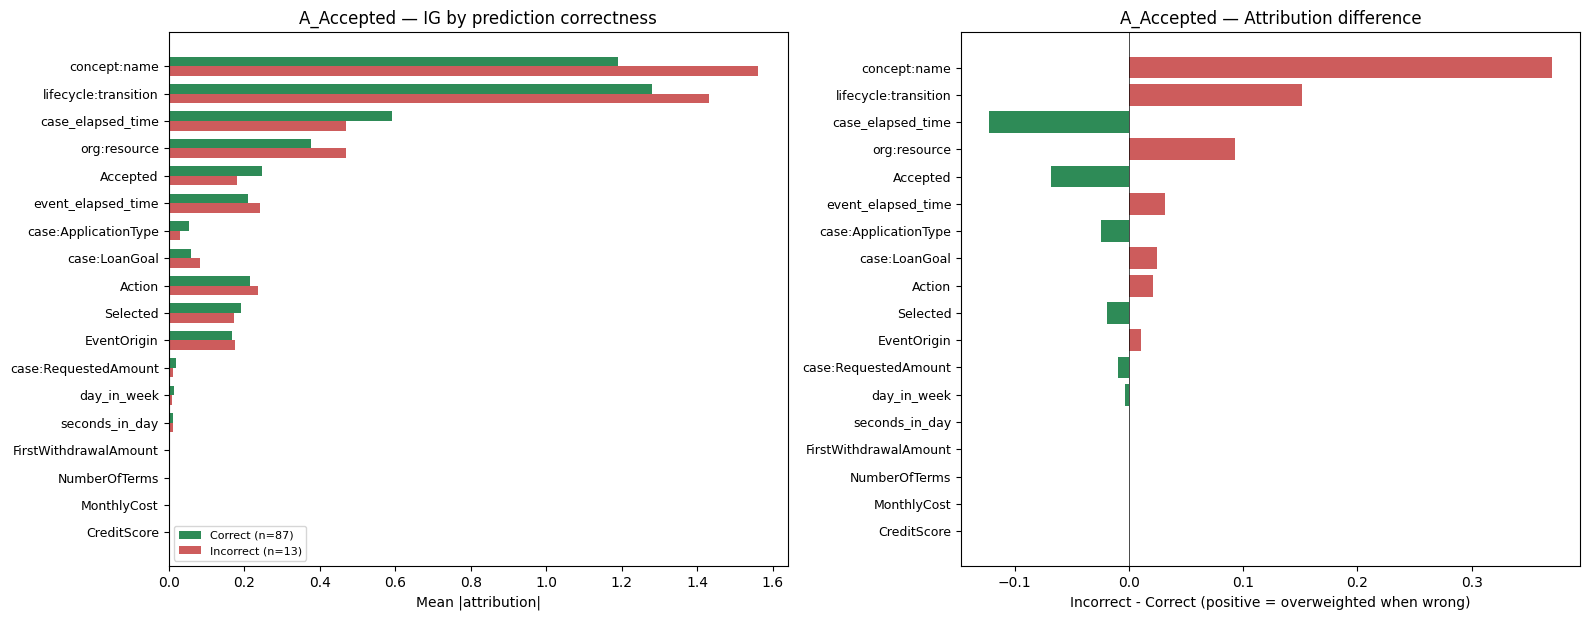

  Overweighted when wrong: concept:name (+0.3701), lifecycle:transition (+0.1513), org:resource (+0.0931)
  Underweighted when wrong: case_elapsed_time (-0.1222), Accepted (-0.0680), case:ApplicationType (-0.0246)


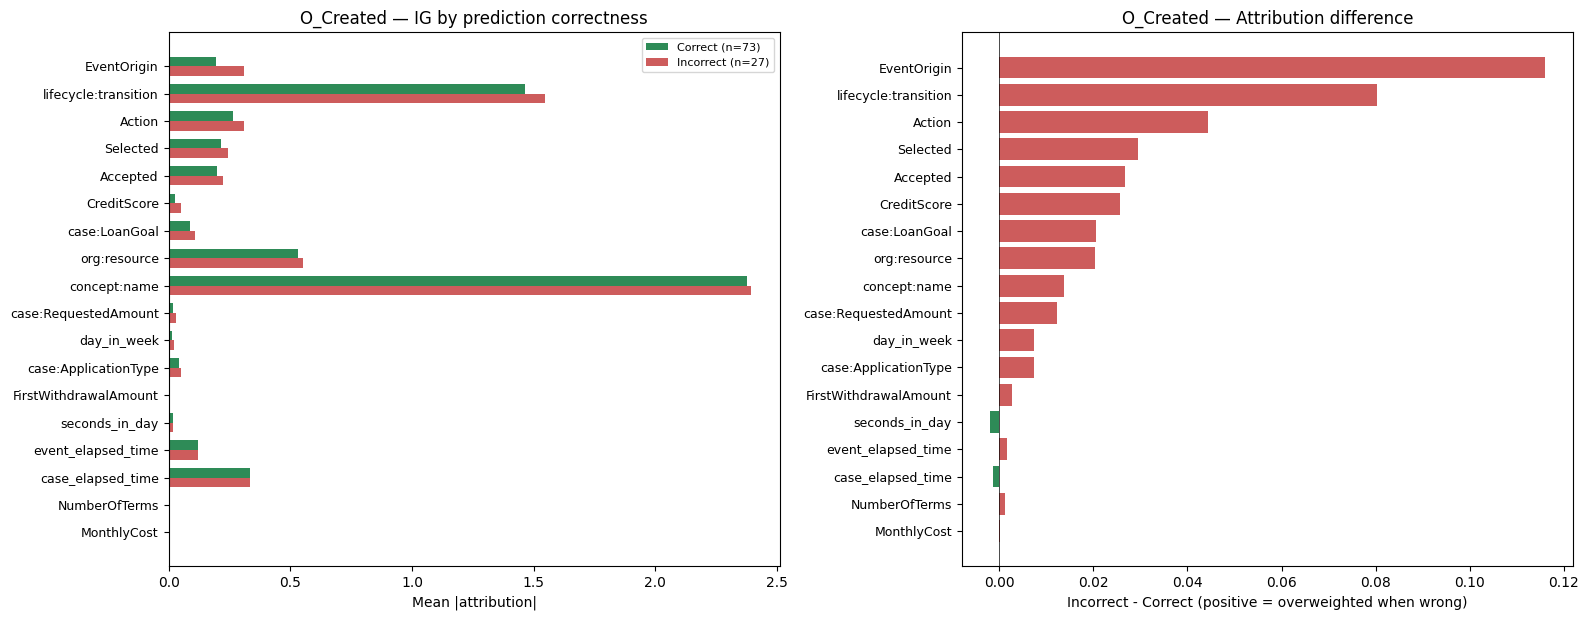

  Overweighted when wrong: EventOrigin (+0.1160), lifecycle:transition (+0.0803), Action (+0.0444)
  Underweighted when wrong: seconds_in_day (-0.0021), case_elapsed_time (-0.0014)


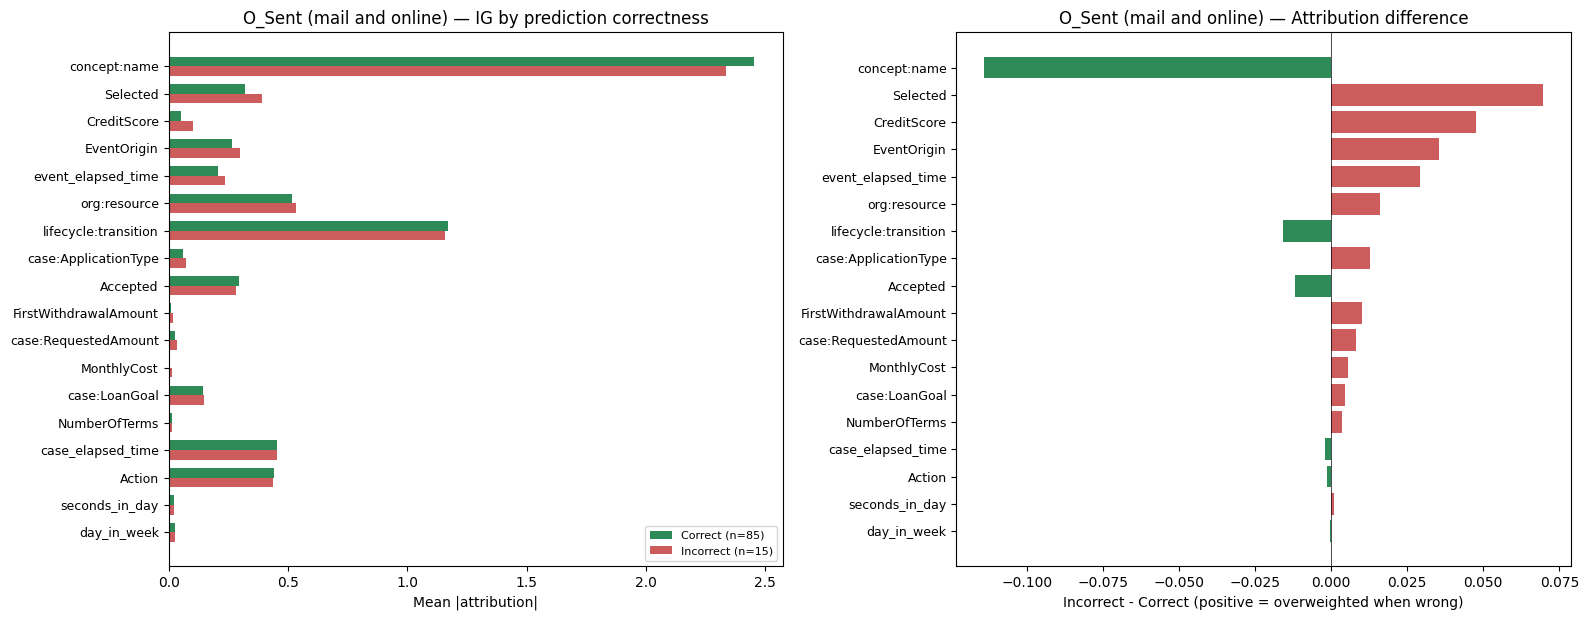

  Overweighted when wrong: Selected (+0.0695), CreditScore (+0.0474), EventOrigin (+0.0356)
  Underweighted when wrong: concept:name (-0.1139), lifecycle:transition (-0.0158), Accepted (-0.0117)


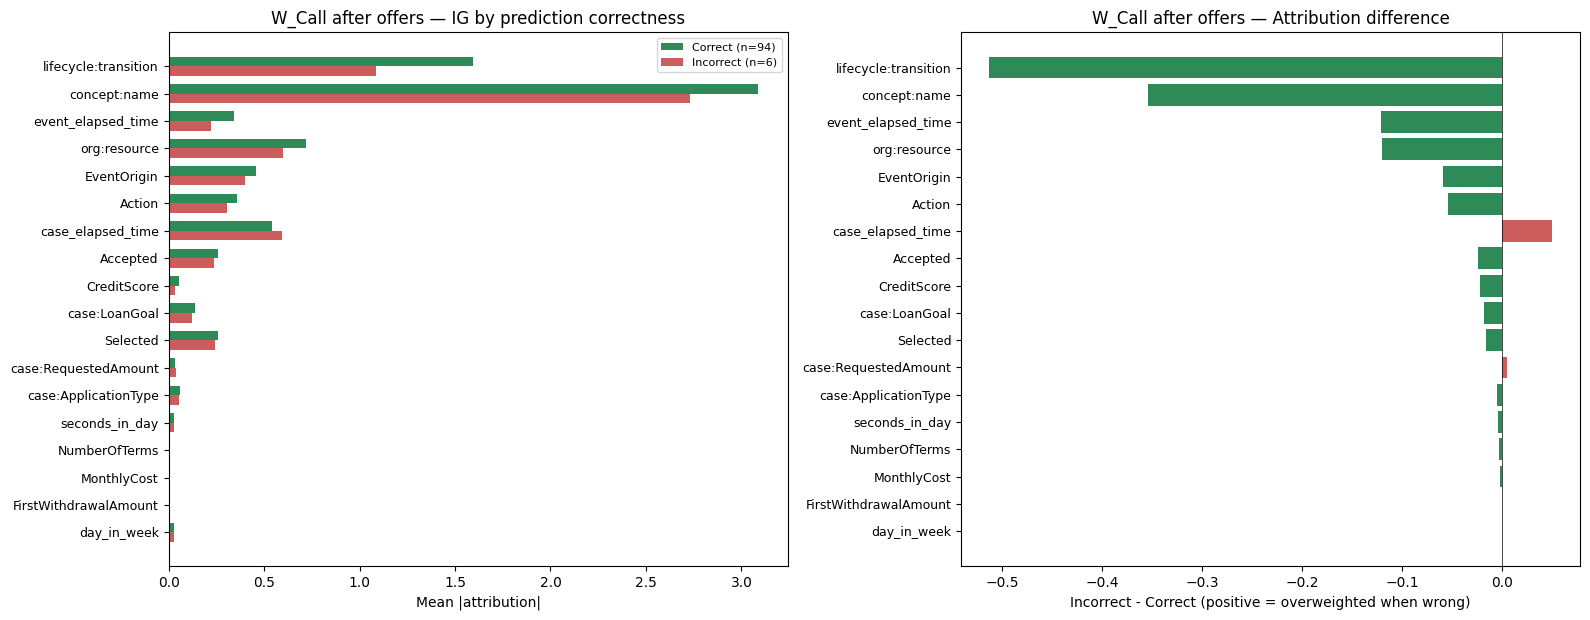

  Overweighted when wrong: case_elapsed_time (+0.0501), case:RequestedAmount (+0.0051), FirstWithdrawalAmount (+0.0005)
  Underweighted when wrong: lifecycle:transition (-0.5128), concept:name (-0.3537), event_elapsed_time (-0.1210)


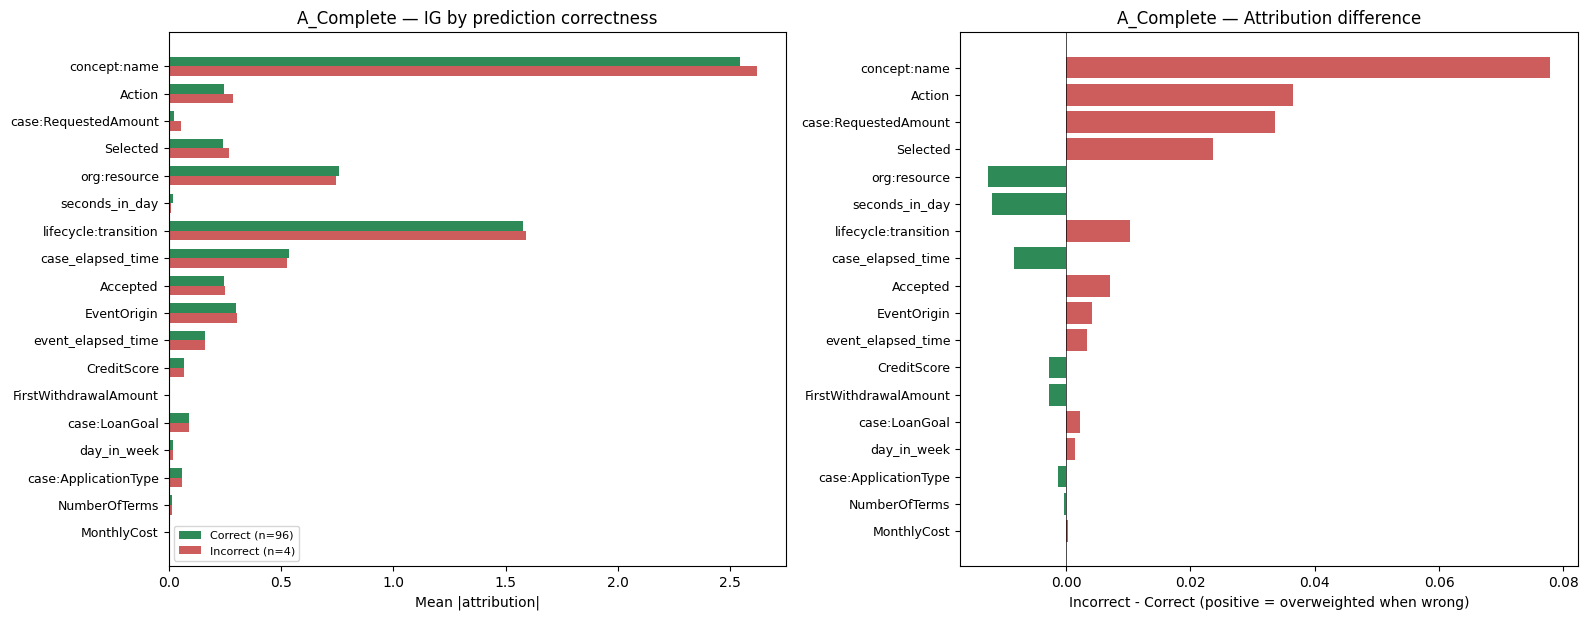

  Overweighted when wrong: concept:name (+0.0778), Action (+0.0365), case:RequestedAmount (+0.0336)
  Underweighted when wrong: org:resource (-0.0125), seconds_in_day (-0.0120), case_elapsed_time (-0.0083)


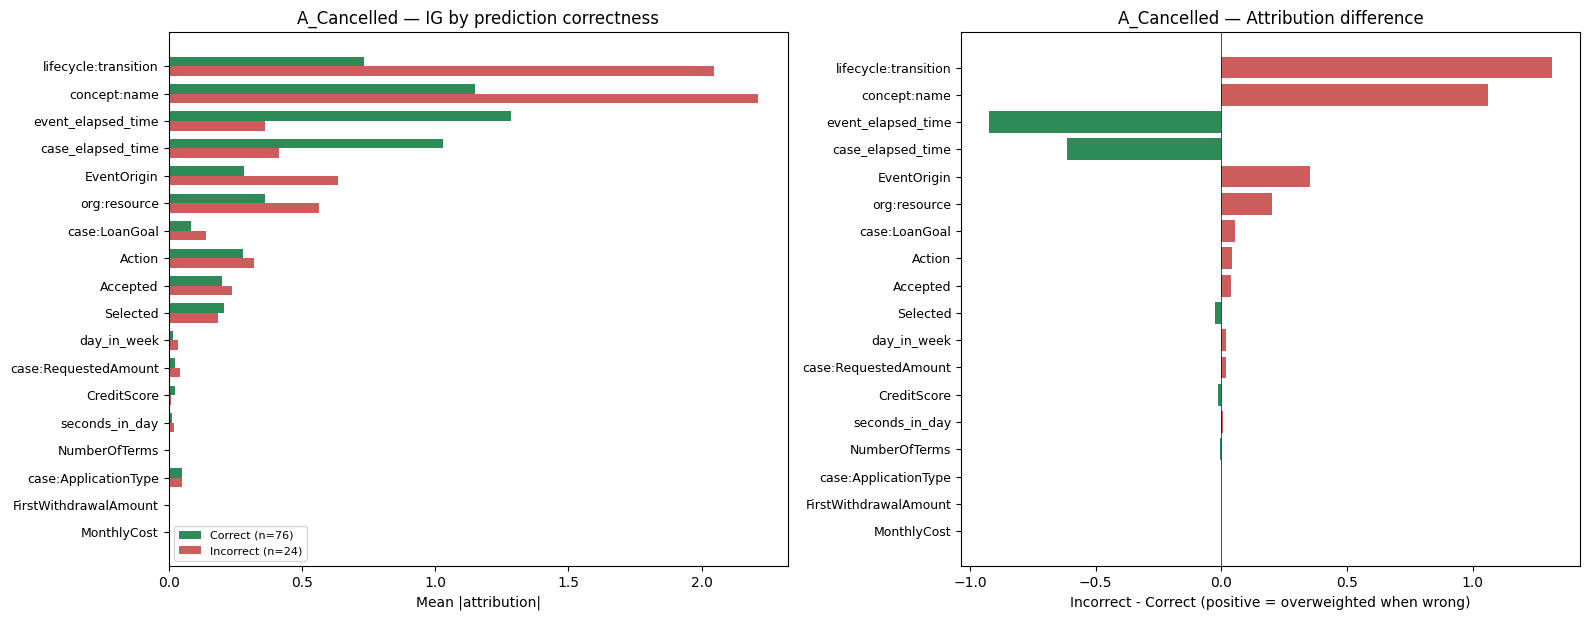

  Overweighted when wrong: lifecycle:transition (+1.3154), concept:name (+1.0625), EventOrigin (+0.3526)
  Underweighted when wrong: event_elapsed_time (-0.9229), case_elapsed_time (-0.6142), Selected (-0.0230)


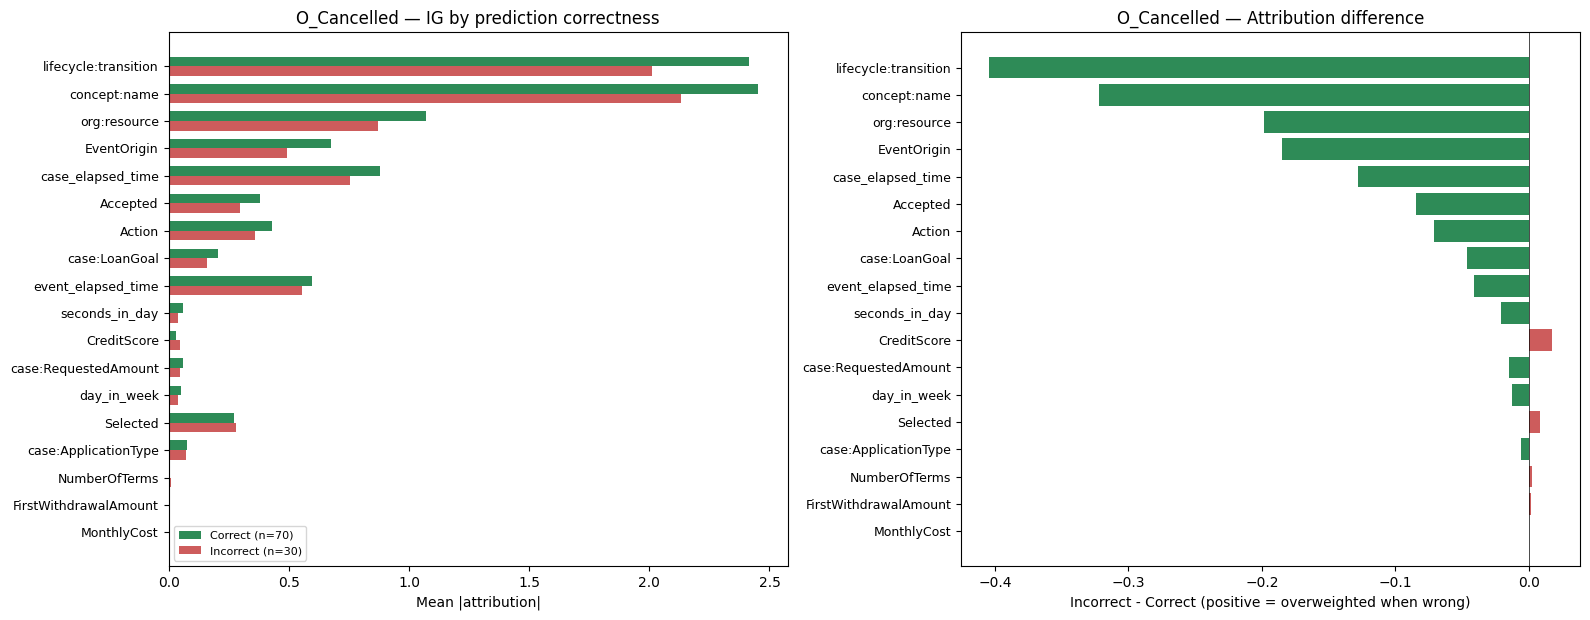

  Overweighted when wrong: CreditScore (+0.0175), Selected (+0.0087), NumberOfTerms (+0.0022)
  Underweighted when wrong: lifecycle:transition (-0.4043), concept:name (-0.3222), org:resource (-0.1980)


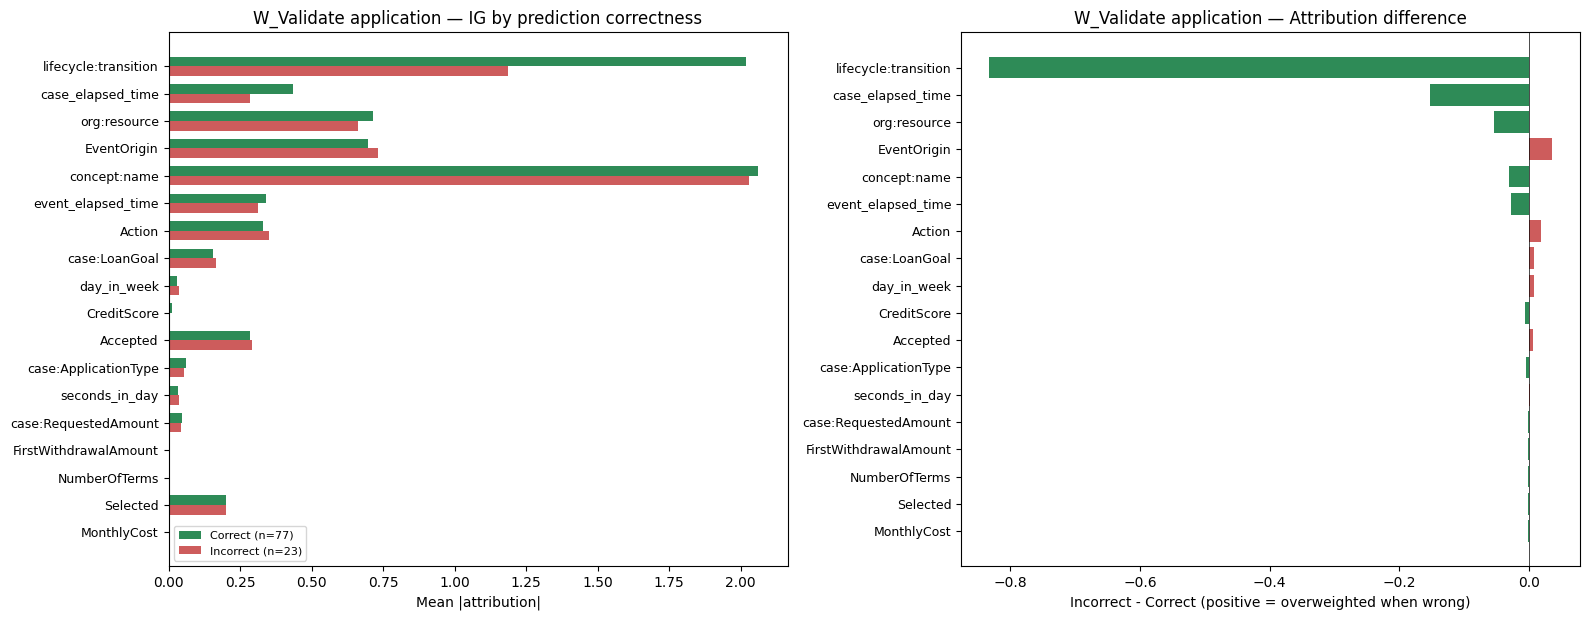

  Overweighted when wrong: EventOrigin (+0.0354), Action (+0.0182), case:LoanGoal (+0.0078)
  Underweighted when wrong: lifecycle:transition (-0.8327), case_elapsed_time (-0.1522), org:resource (-0.0537)


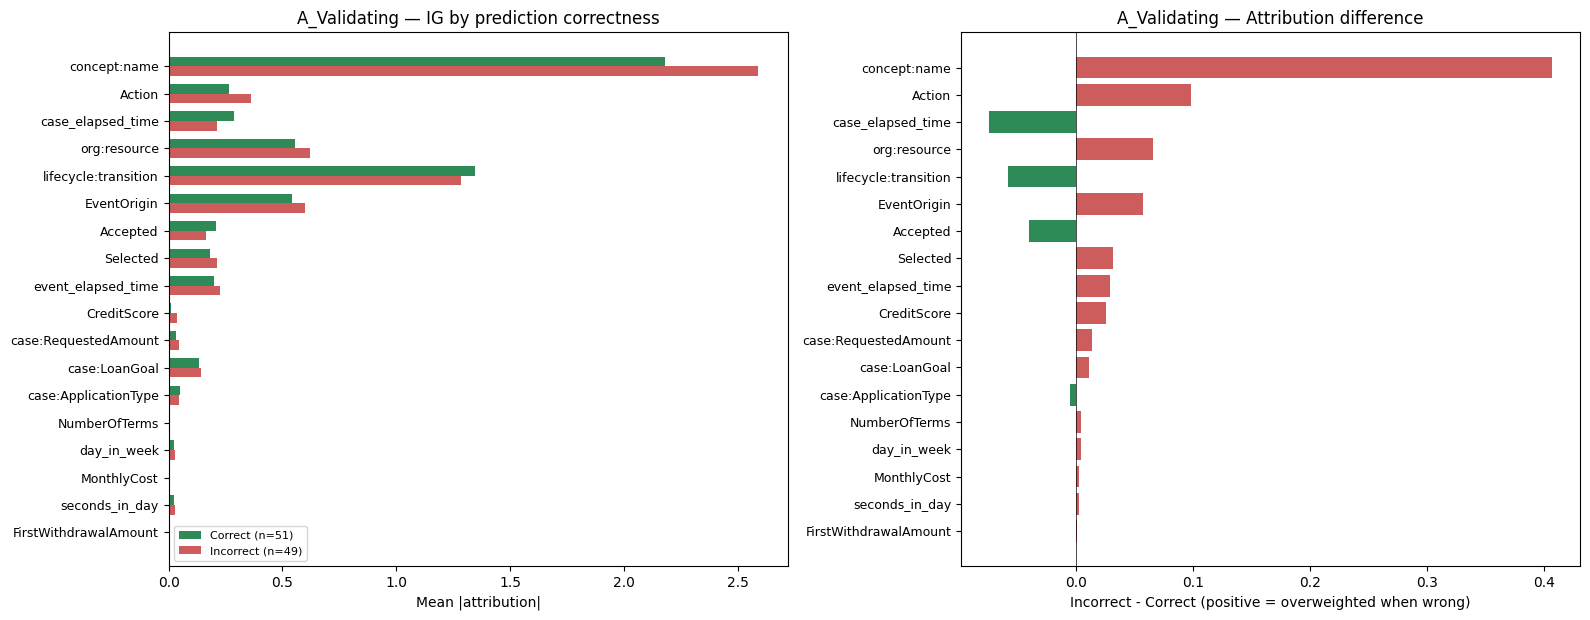

  Overweighted when wrong: concept:name (+0.4071), Action (+0.0982), org:resource (+0.0655)
  Underweighted when wrong: case_elapsed_time (-0.0745), lifecycle:transition (-0.0583), Accepted (-0.0405)


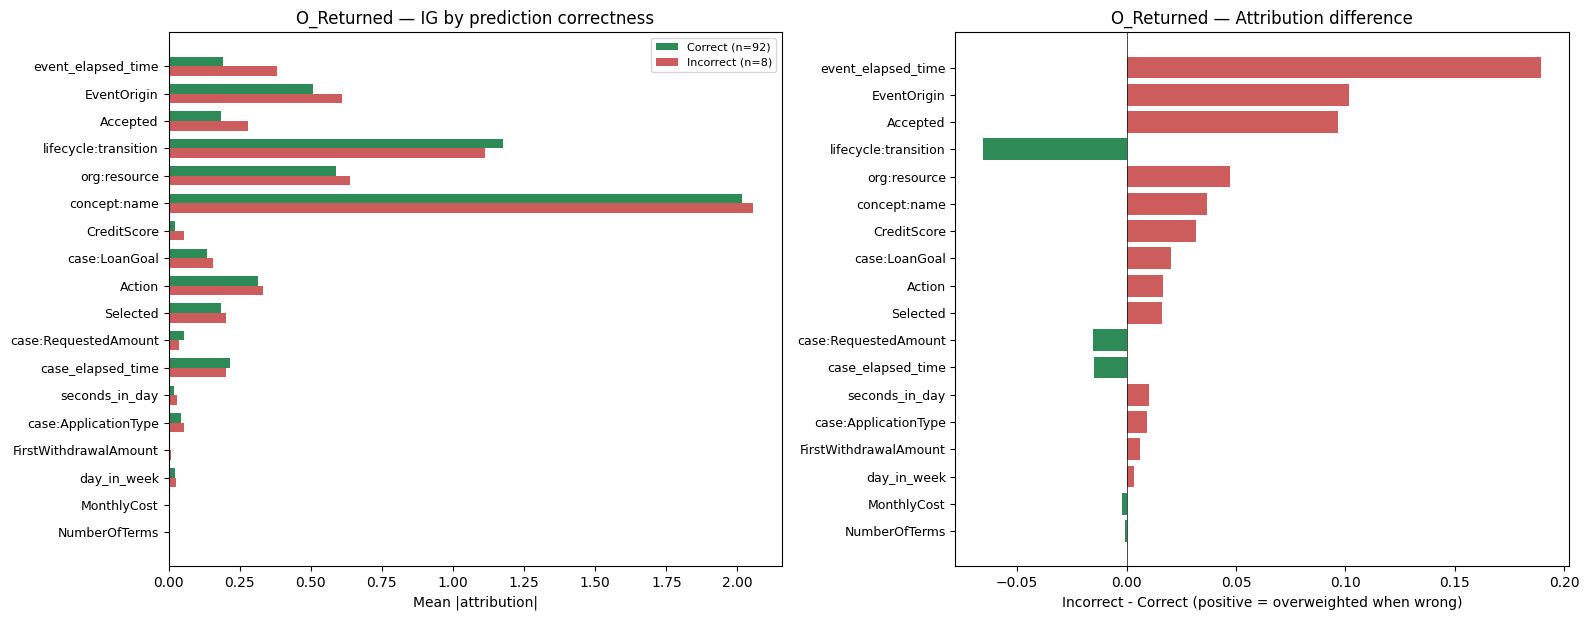

  Overweighted when wrong: event_elapsed_time (+0.1893), EventOrigin (+0.1017), Accepted (+0.0967)
  Underweighted when wrong: lifecycle:transition (-0.0654), case:RequestedAmount (-0.0153), case_elapsed_time (-0.0148)


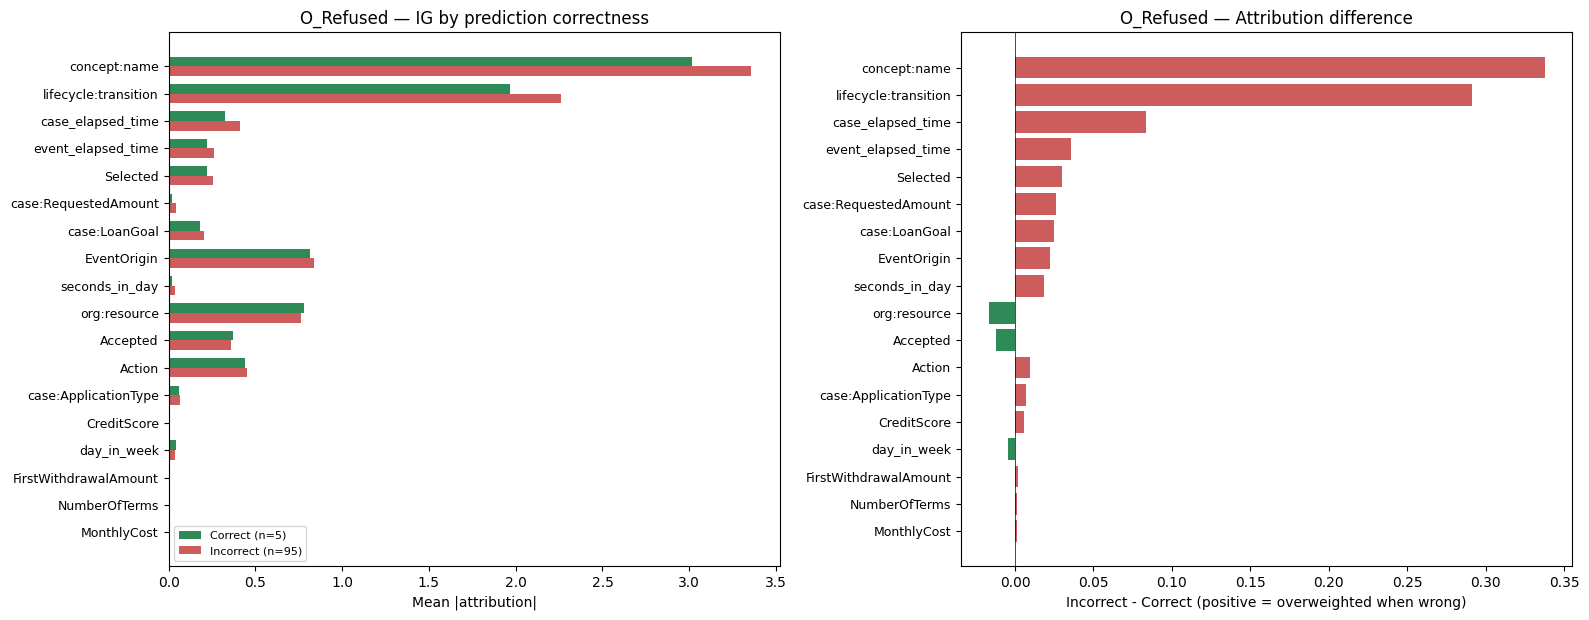

  Overweighted when wrong: concept:name (+0.3376), lifecycle:transition (+0.2914), case_elapsed_time (+0.0835)
  Underweighted when wrong: org:resource (-0.0168), Accepted (-0.0123), day_in_week (-0.0048)


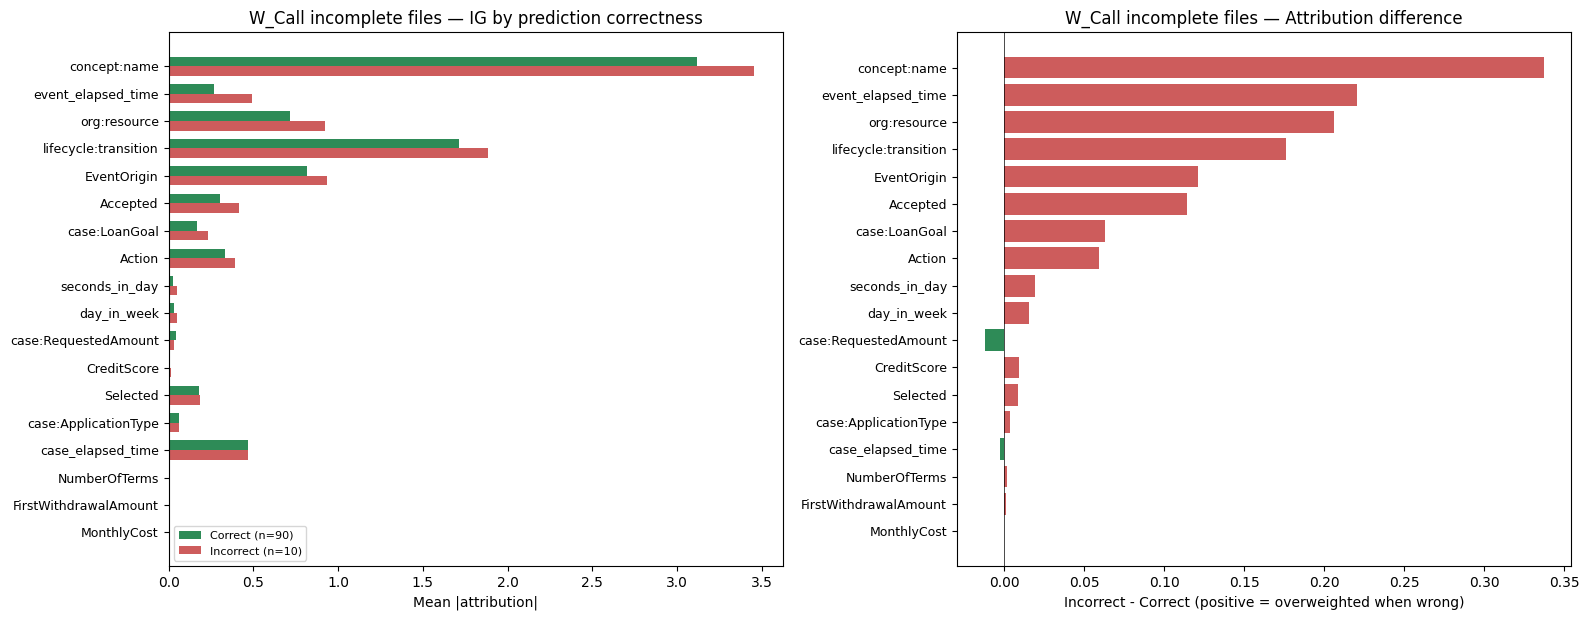

  Overweighted when wrong: concept:name (+0.3372), event_elapsed_time (+0.2202), org:resource (+0.2062)
  Underweighted when wrong: case:RequestedAmount (-0.0123), case_elapsed_time (-0.0029), MonthlyCost (-0.0005)
A_Incomplete: only 2 incorrect predictions, skipping


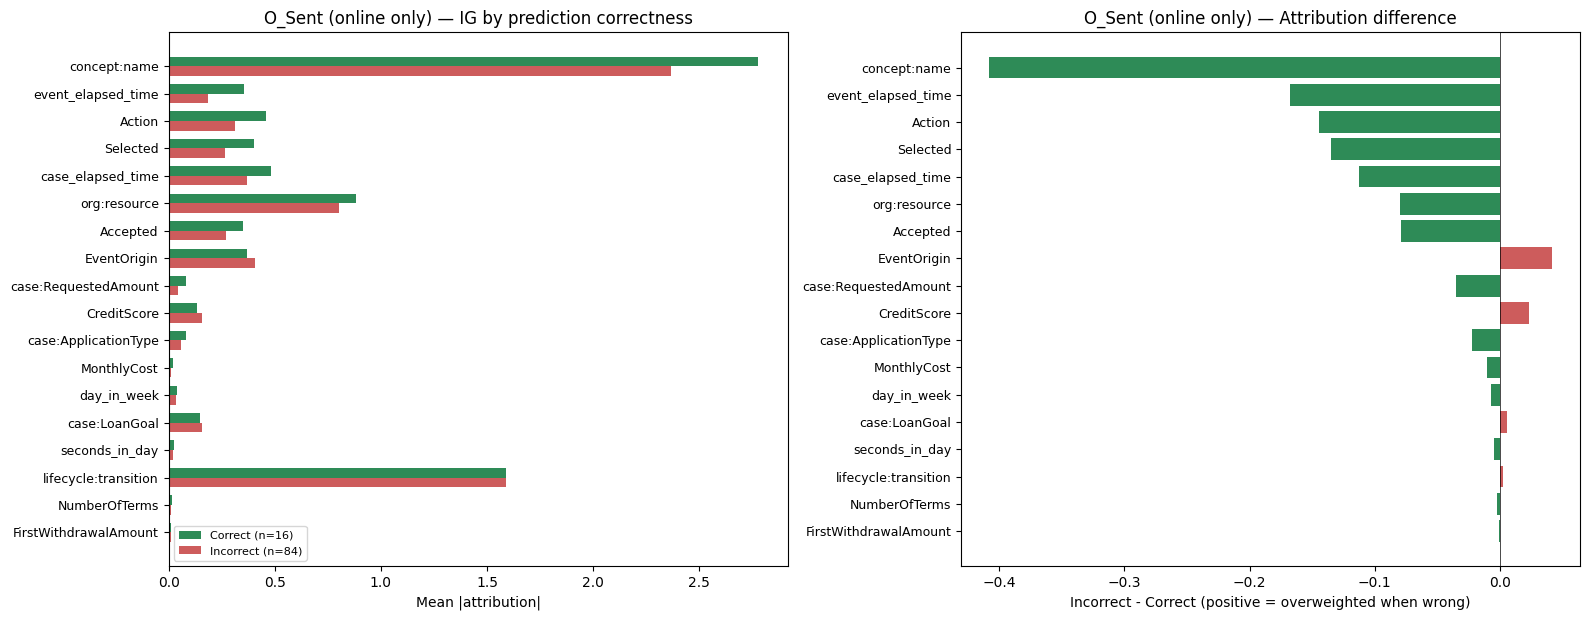

  Overweighted when wrong: EventOrigin (+0.0416), CreditScore (+0.0234), case:LoanGoal (+0.0058)
  Underweighted when wrong: concept:name (-0.4080), event_elapsed_time (-0.1675), Action (-0.1446)


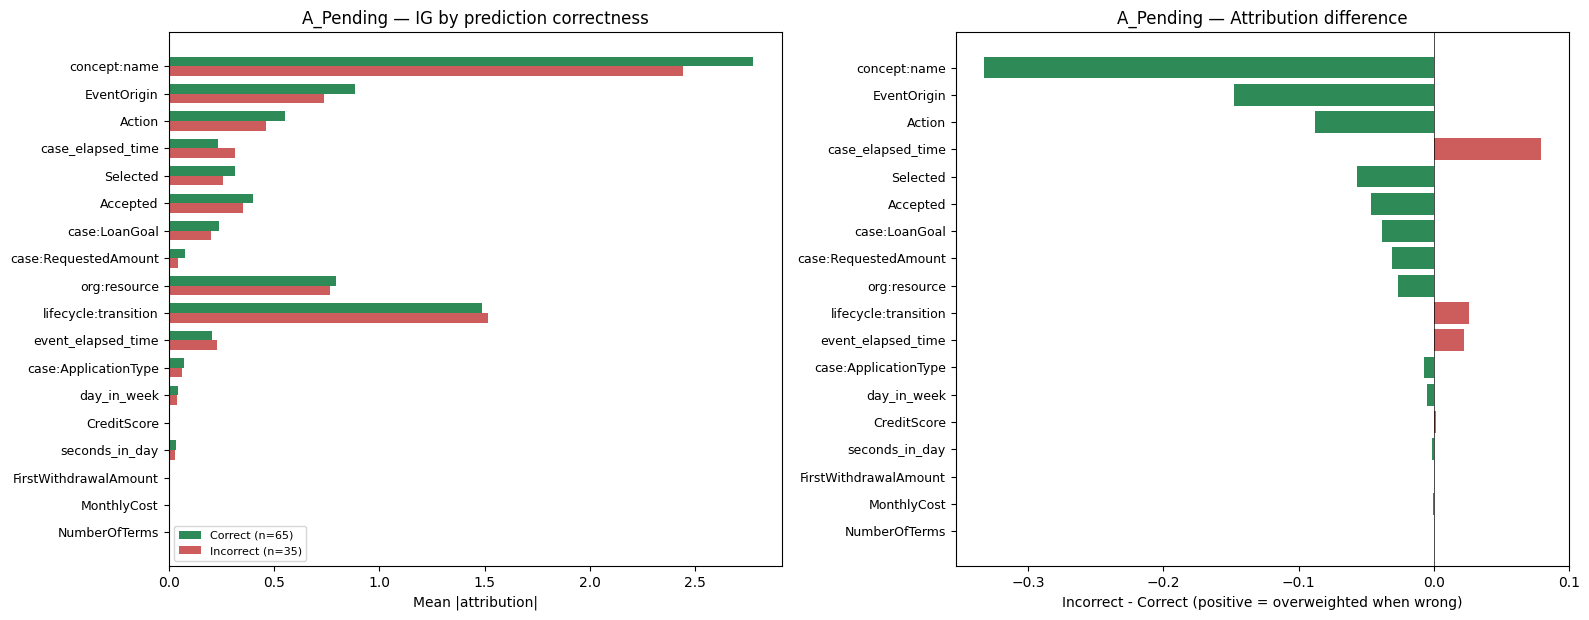

  Overweighted when wrong: case_elapsed_time (+0.0796), lifecycle:transition (+0.0258), event_elapsed_time (+0.0221)
  Underweighted when wrong: concept:name (-0.3329), EventOrigin (-0.1475), Action (-0.0879)


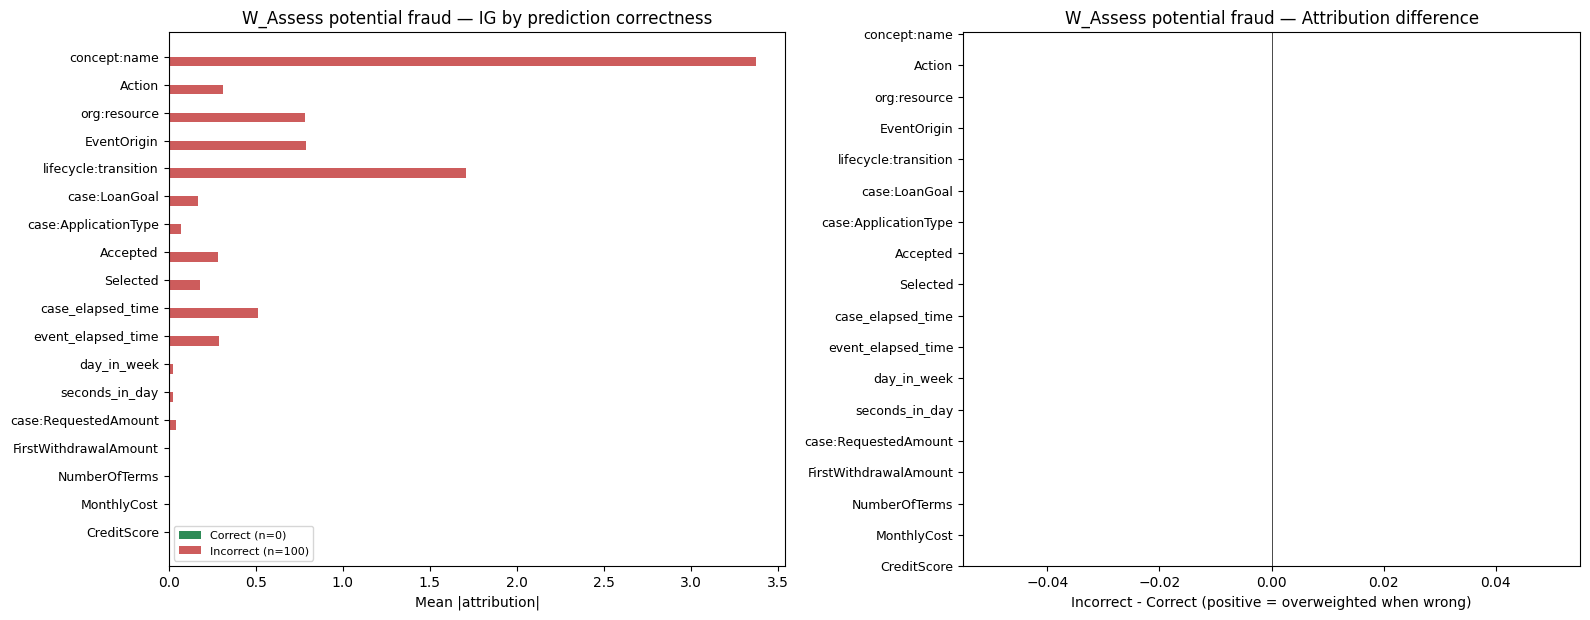

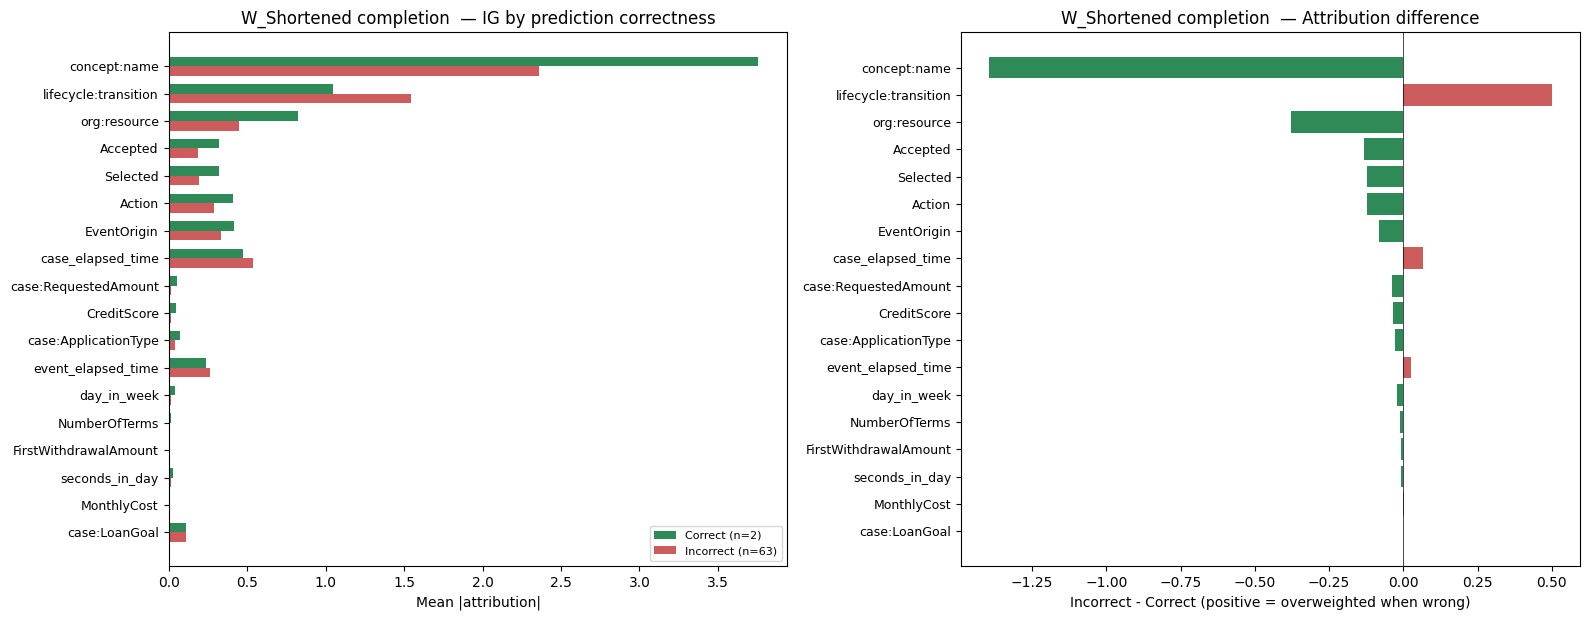

  Overweighted when wrong: lifecycle:transition (+0.5002), case_elapsed_time (+0.0654), event_elapsed_time (+0.0273)
  Underweighted when wrong: concept:name (-1.3943), org:resource (-0.3784), Accepted (-0.1329)


In [9]:
for gateway_act in ig_results:
    ig_df = ig_results[gateway_act]
    ig_features = [f for f in ALL_FEATURES if f in ig_df.columns]

    correct = ig_df[ig_df['y_lstm'] == ig_df['y_actual']]
    incorrect = ig_df[ig_df['y_lstm'] != ig_df['y_actual']]

    if len(incorrect) < 3:
        print(f'{gateway_act}: only {len(incorrect)} incorrect predictions, skipping')
        continue

    mean_correct = correct[ig_features].mean()
    mean_incorrect = incorrect[ig_features].mean()

    diff = mean_incorrect - mean_correct
    order = diff.abs().sort_values(ascending=False).index
    mean_correct = mean_correct[order]
    mean_incorrect = mean_incorrect[order]
    diff = diff[order]

    fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(ig_features) * 0.35)))

    y_pos = np.arange(len(order))
    bar_h = 0.35
    ax = axes[0]
    ax.barh(y_pos - bar_h / 2, mean_correct.values, bar_h,
            label=f'Correct (n={len(correct)})', color='seagreen')
    ax.barh(y_pos + bar_h / 2, mean_incorrect.values, bar_h,
            label=f'Incorrect (n={len(incorrect)})', color='indianred')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(order, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Mean |attribution|')
    ax.set_title(f'{gateway_act} — IG by prediction correctness')
    ax.legend(fontsize=8)

    ax = axes[1]
    colors = ['indianred' if d > 0 else 'seagreen' for d in diff.values]
    ax.barh(y_pos, diff.values, color=colors)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(order, fontsize=9)
    ax.invert_yaxis()
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Incorrect - Correct (positive = overweighted when wrong)')
    ax.set_title(f'{gateway_act} — Attribution difference')

    plt.tight_layout()
    plt.show()

    top_over = diff[diff > 0].head(3)
    top_under = diff[diff < 0].head(3)
    if len(top_over) > 0:
        print(f'  Overweighted when wrong: {", ".join(f"{f} (+{v:.4f})" for f, v in top_over.items())}')
    if len(top_under) > 0:
        print(f'  Underweighted when wrong: {", ".join(f"{f} ({v:.4f})" for f, v in top_under.items())}')

## IG only per gateway

LSTM attribution (mean `|IG|` per feature) for each gateway, without the
surrogate / ground-truth Gini overlays.

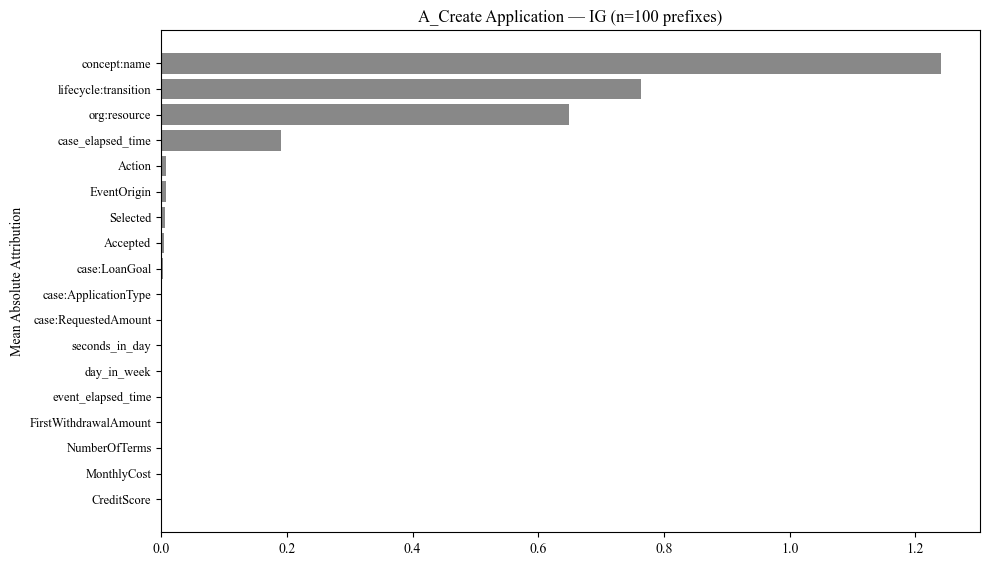

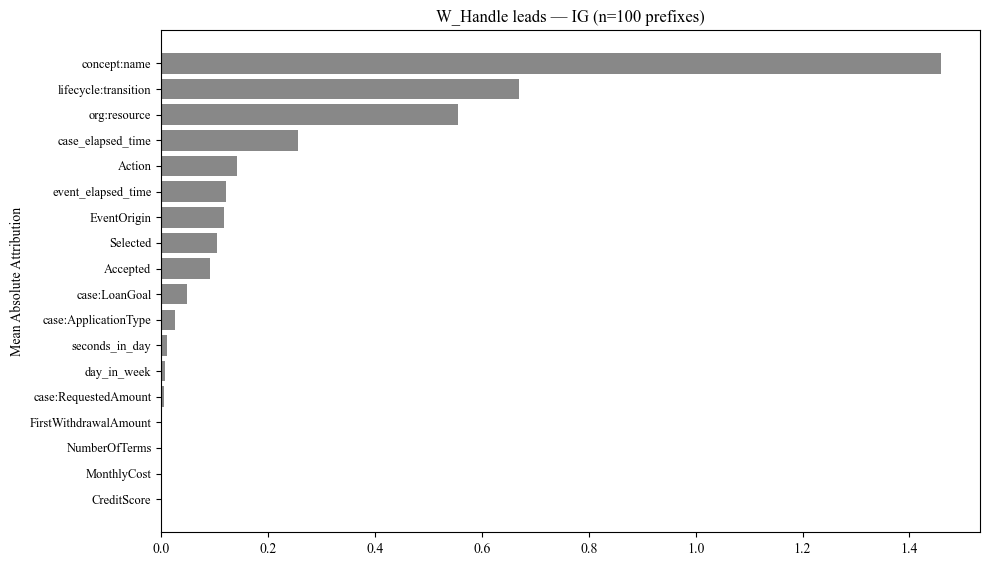

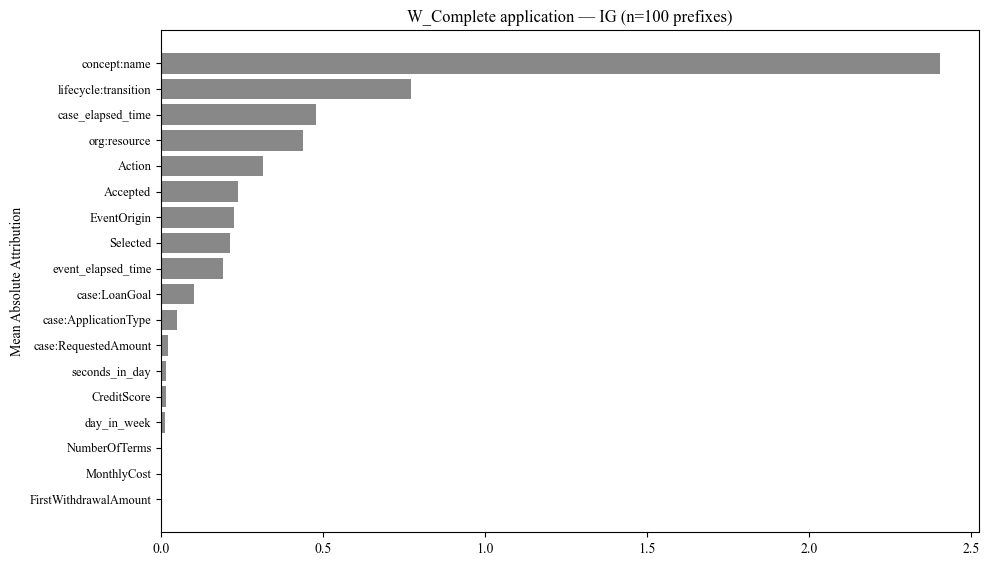

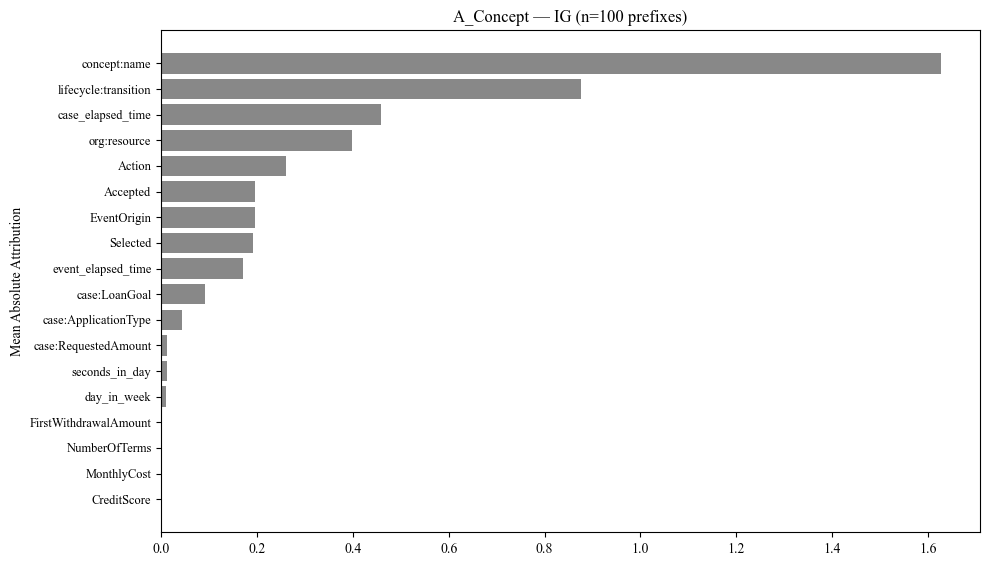

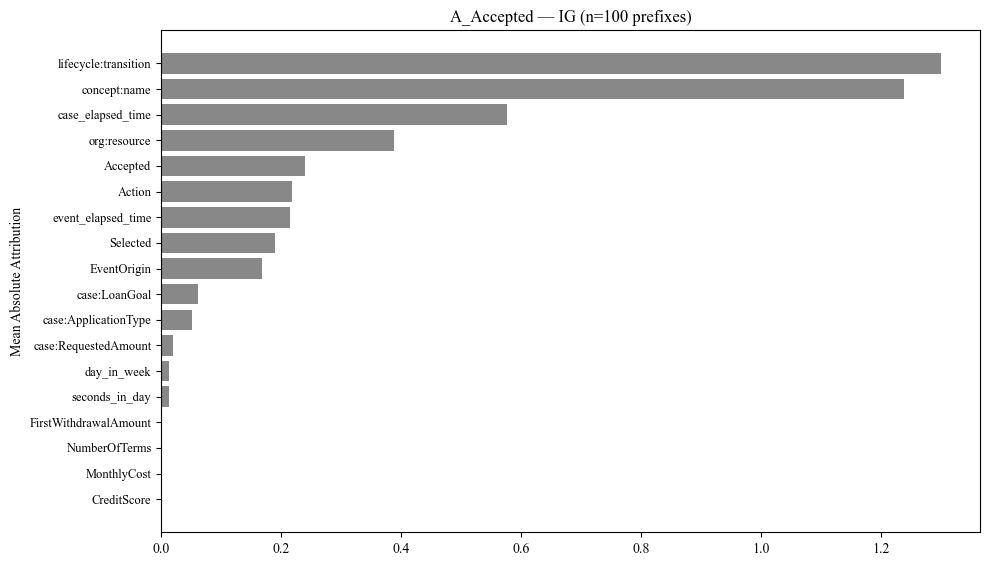

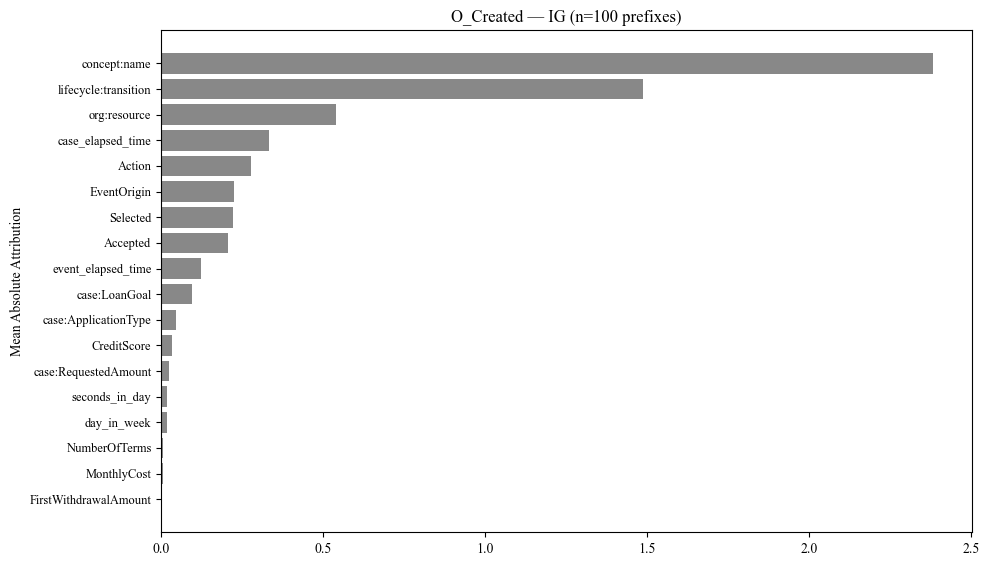

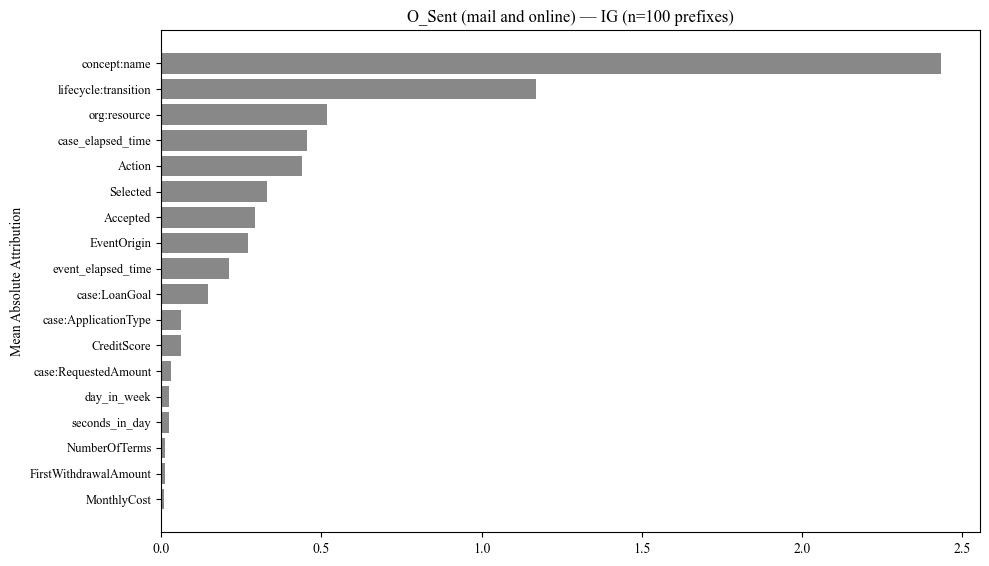

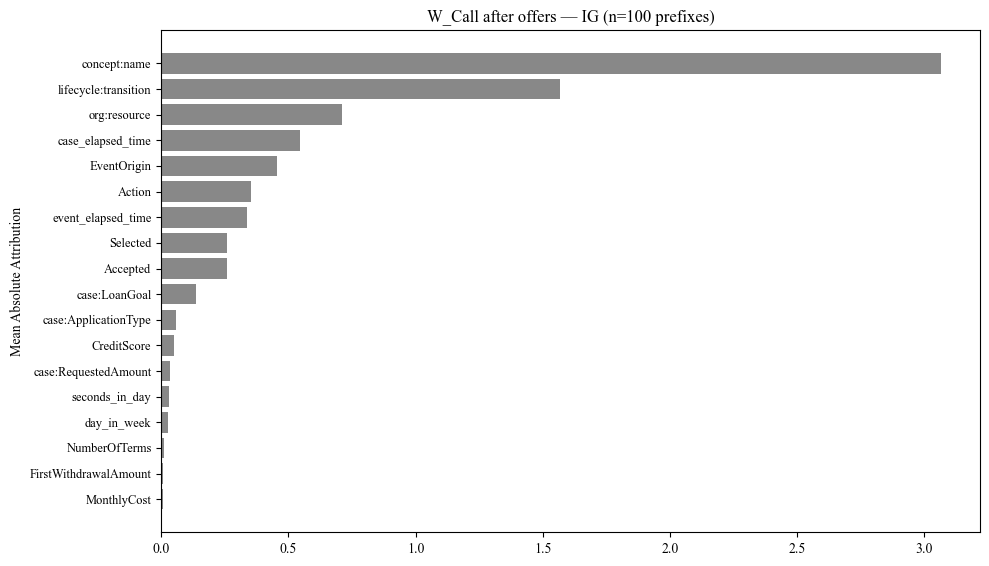

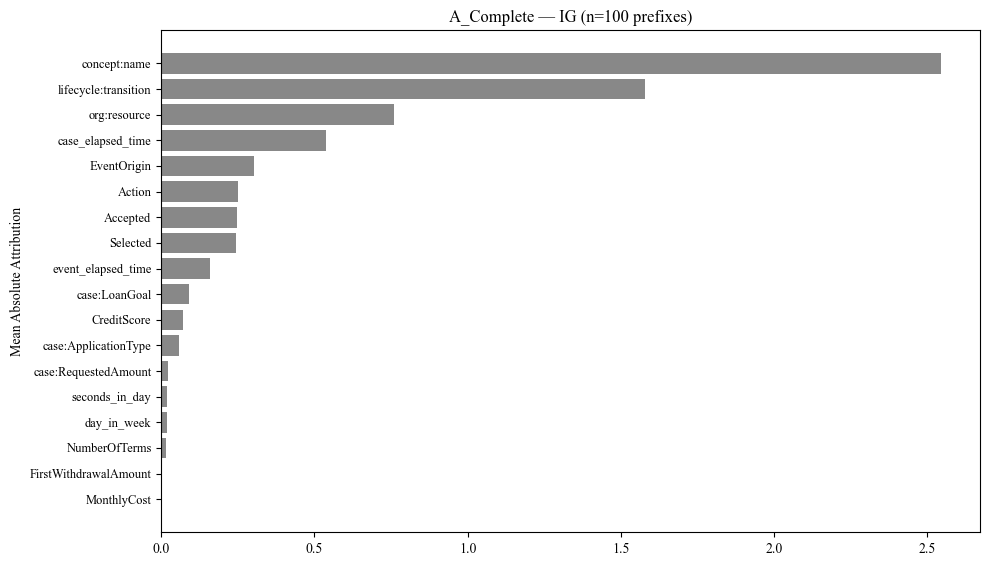

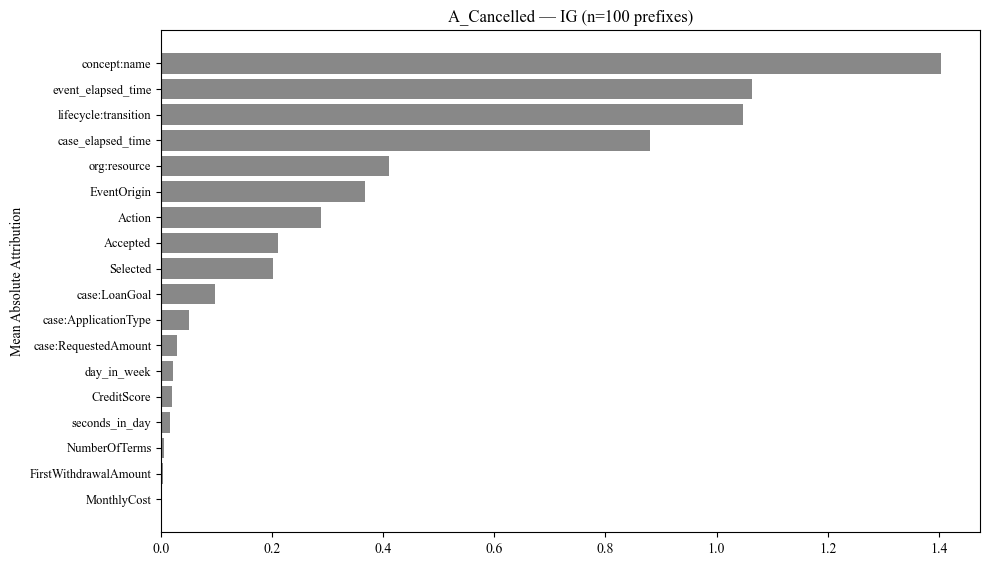

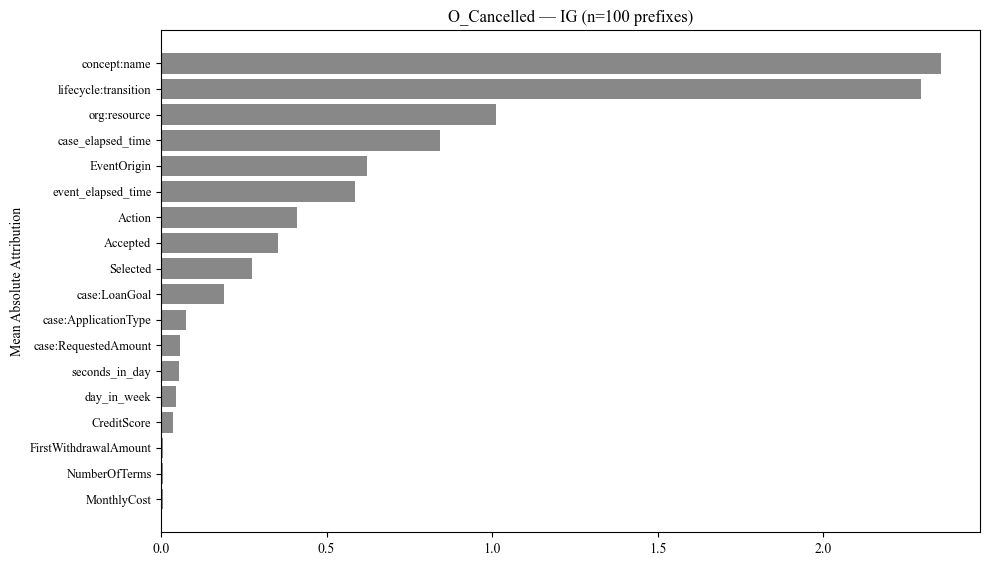

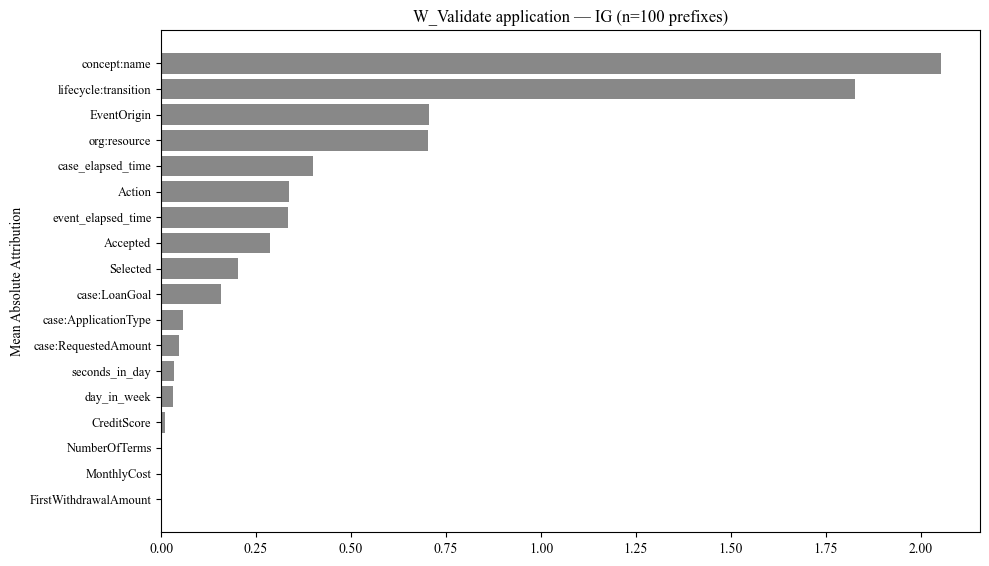

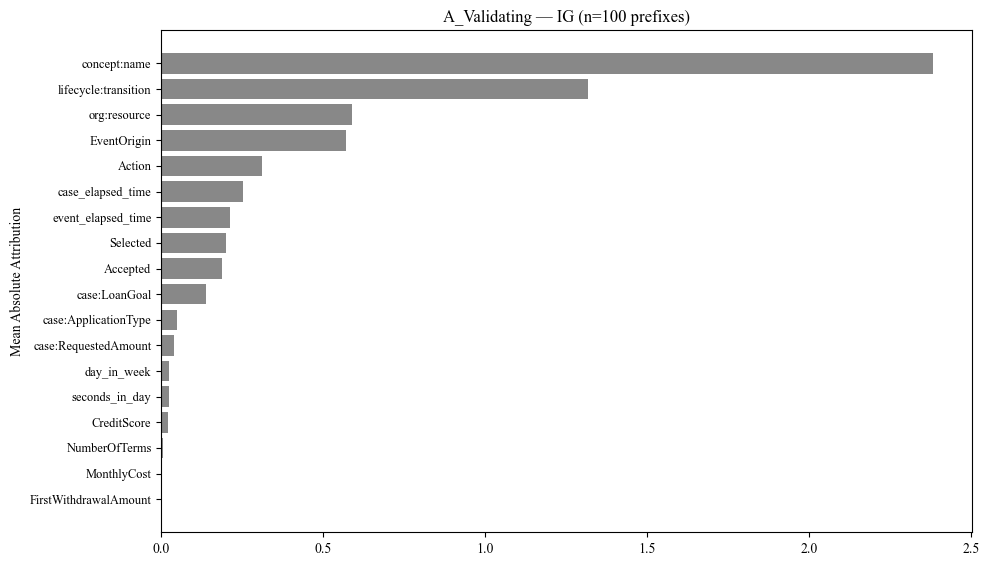

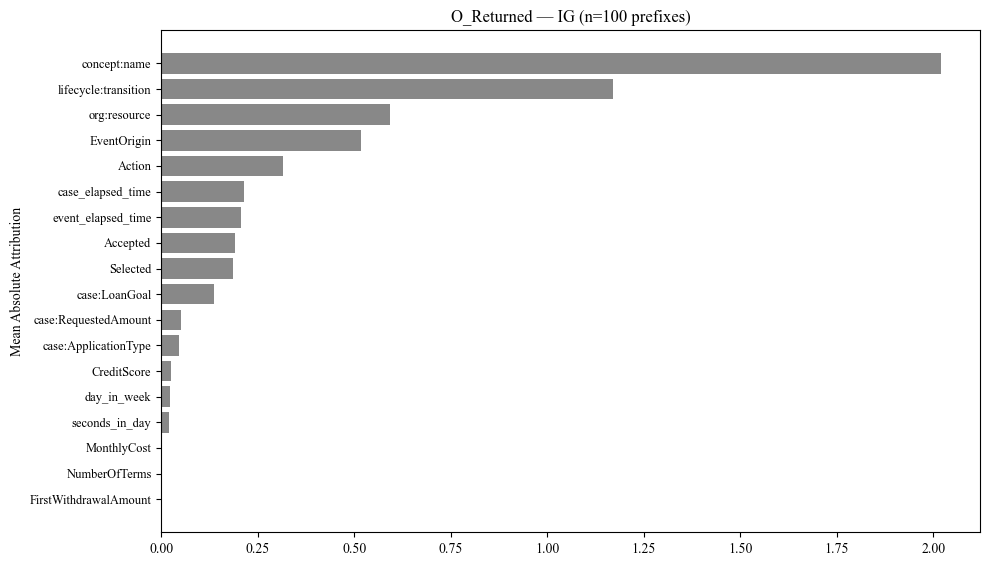

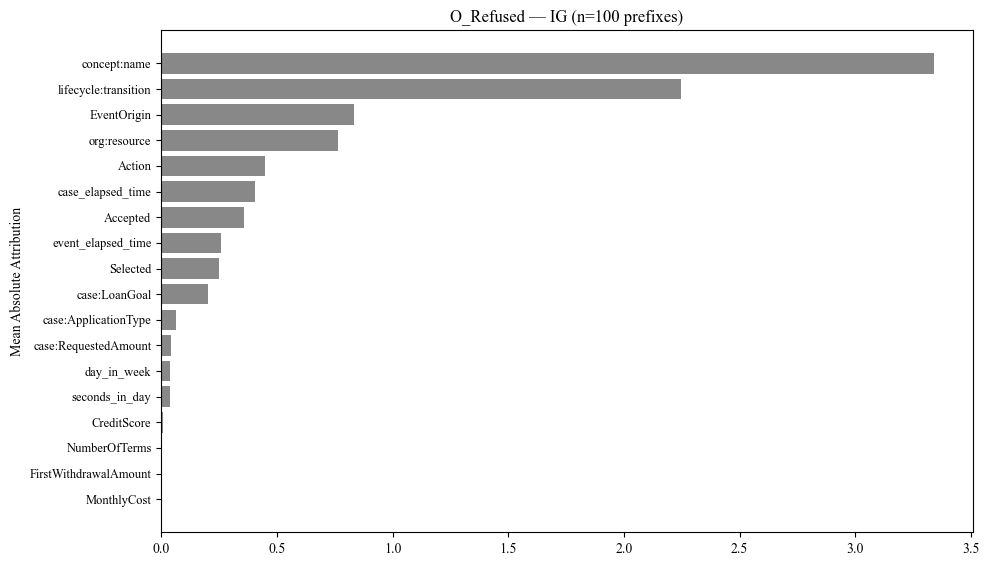

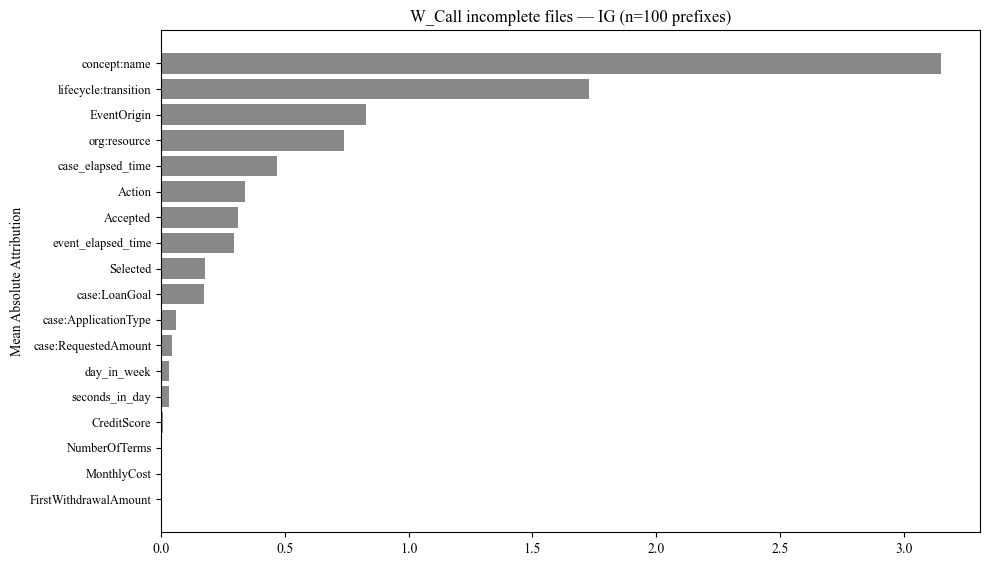

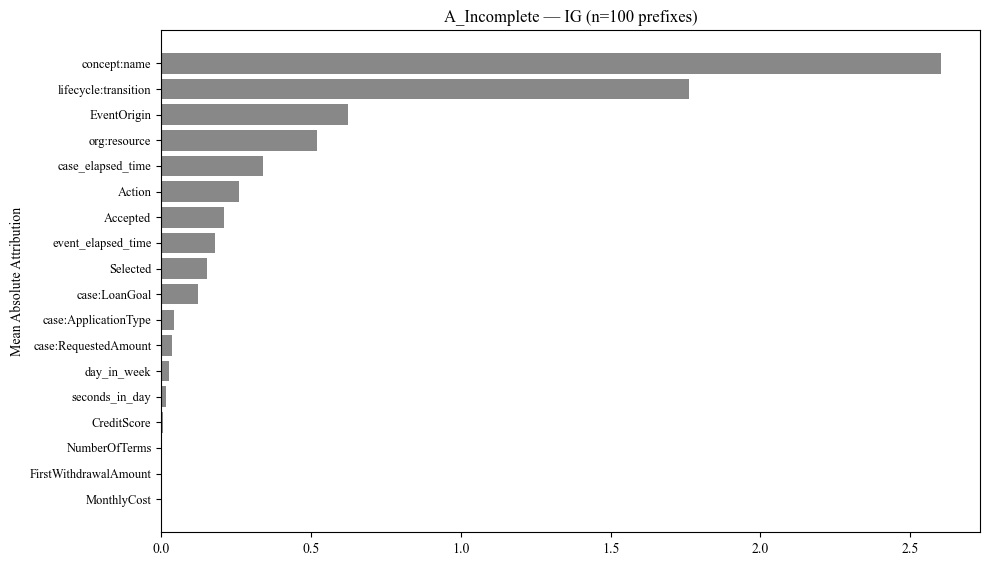

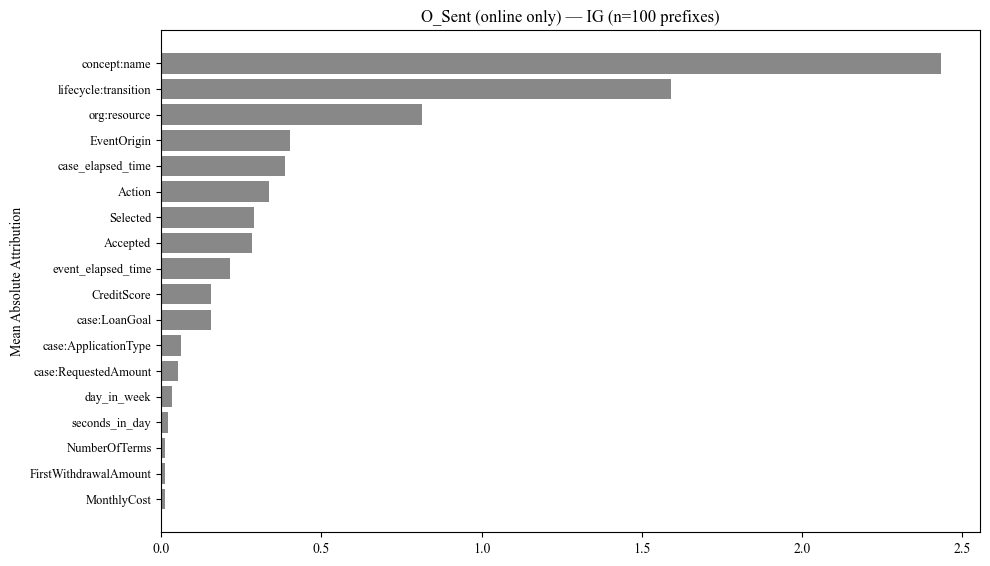

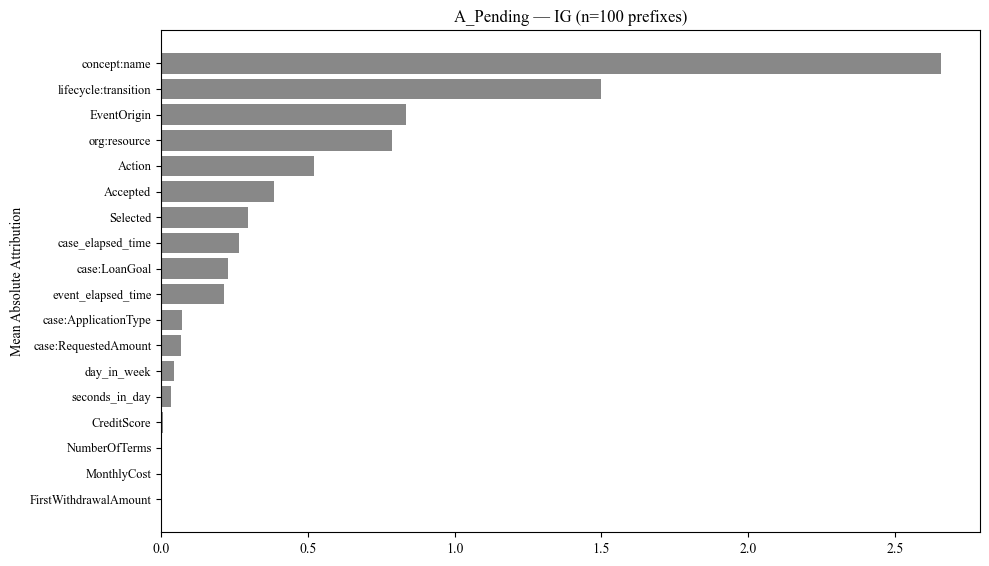

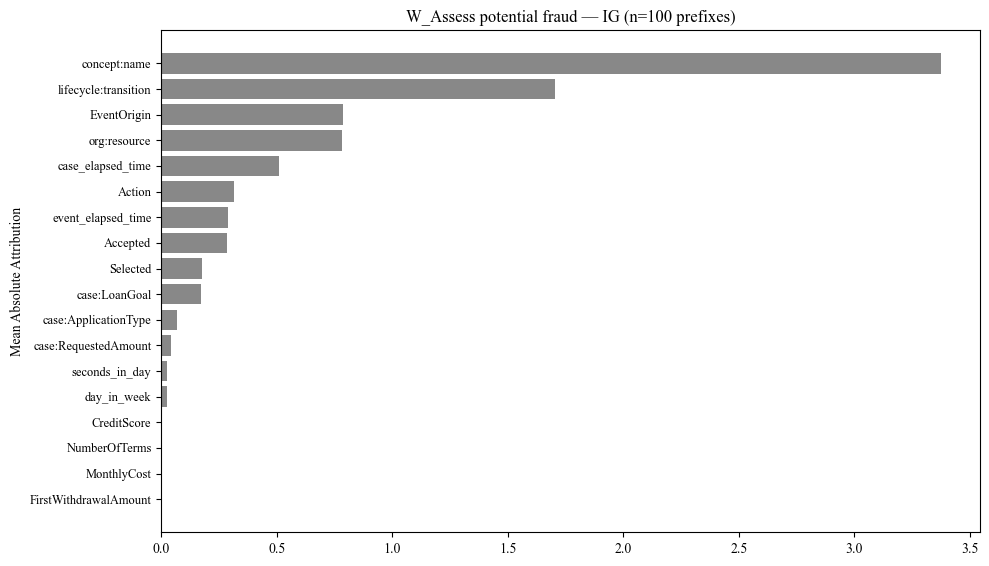

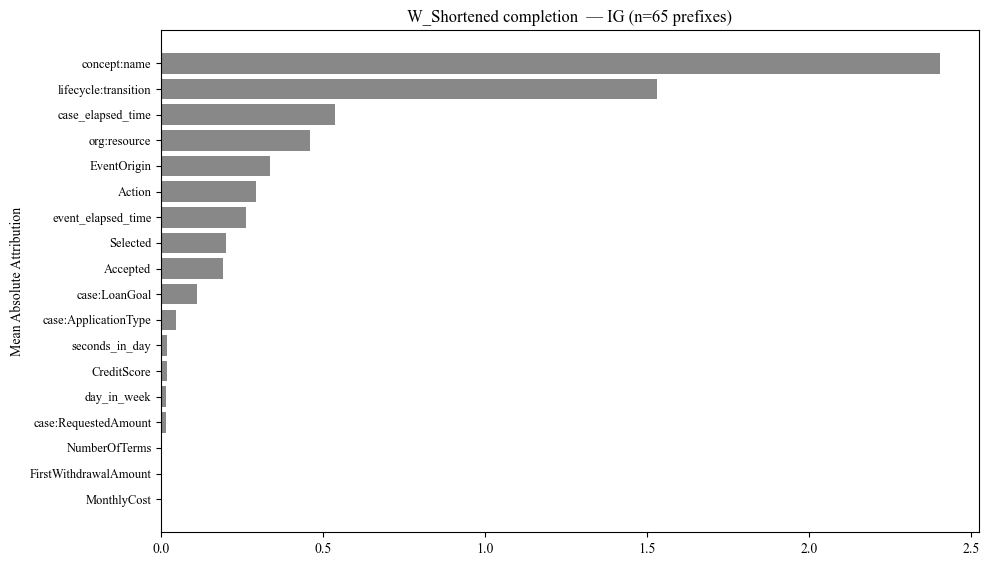

In [11]:
# IG-only bar plot per gateway. Uses the same ig_results computed above; no
# Gini overlays from the surrogate / GT trees.


plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Times', 'Liberation Serif', 'DejaVu Serif']



for gateway_act in ig_results:
    ig_df = ig_results[gateway_act]
    ig_features = [f for f in ALL_FEATURES if f in ig_df.columns]
    ig_mean = ig_df[ig_features].mean().sort_values(ascending=False)

    n = len(ig_mean)
    if n == 0:
        continue

    fig, ax = plt.subplots(figsize=(10, max(3.5, n * 0.32)))
    y_pos = np.arange(n)
    ax.barh(y_pos, ig_mean.values, color='#888888')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(ig_mean.index, fontsize=9)
    ax.invert_yaxis()
    ax.set_ylabel('Mean Absolute Attribution')
    ax.set_title(f'{gateway_act} — IG (n={len(ig_df)} prefixes)')
    plt.tight_layout()
    plt.show()